# EDA — Dataset Tarea 2 · Extracción de Contribuciones Científicas
**Proyecto de Grado MAIA · Universidad de los Andes · v2 · Abril 2026**

---

Dataset para clasificación binaria de fragmentos de artículos científicos en español:

| Clase | Etiqueta | Descripción |
|-------|----------|-------------|
| 1 | `ES_CONTRIBUCION` | El fragmento describe un aporte científico original |
| 0 | `NO_ES_CONTRIBUCION` | No contiene formulación explícita de contribución |

**Arquitectura A1–A3:**
- **Pool A1**: 2 000 fragmentos balanceados (1 000 pos + 1 000 neg)  
- **A3 ANTES**: marcadores intactos → train (1 440) + val (360)  
- **A3 DESPUÉS**: 40 % positivos neutralizados + 30 % negativos con frase inyectada  
- **EVAL**: 200 fragmentos validados por humanos (170 consenso = test oficial)


In [4]:
import json, re, zipfile, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

try:
    from wordcloud import WordCloud
    HAS_WC = True
except ImportError:
    HAS_WC = False
    print("wordcloud no disponible – celdas de nube omitidas")

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 80)

# ── Paleta y estilo global ─────────────────────────────────────────────────
AZUL    = '#1F4E79'
AZUL2   = '#2E75B6'
VERDE   = '#375623'
ROJO    = '#C00000'
NARANJ  = '#E36C09'
GRIS    = '#595959'
AZUL_CL = '#D6E4F0'
VERDE_CL= '#E2EFDA'

PAL = {'ES_CONTRIBUCION': AZUL2, 'NO_ES_CONTRIBUCION': NARANJ}

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 11,
    'figure.titlesize': 13,
    'figure.titleweight': 'bold',
})

print("Librerías cargadas ✓")


Librerías cargadas ✓


## 1 · Carga del Dataset

In [5]:
# ── Ajusta esta ruta al ZIP descargado o a la carpeta extraída ─────────────
ZIP_PATH     = './20260420_dataset_CONTRv2.zip'   # <- ajustar si es necesario
DATASET_DIR  = './dataset_v2'

if Path(ZIP_PATH).exists() and not Path(DATASET_DIR).exists():
    print(f"Extrayendo {ZIP_PATH} …")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATASET_DIR)
    print("Extraído ✓")

BASE = Path(DATASET_DIR)
# Normalizar rutas según lo que haya en el ZIP
TRAIN_ANT = next((p for p in [BASE/'train.jsonl',
                               BASE/'mnt/user-data/outputs/dataset_a3/antes/train.jsonl']
                  if p.exists()), None)
VAL_ANT   = next((p for p in [BASE/'val.jsonl',
                               BASE/'mnt/user-data/outputs/dataset_a3/antes/val.jsonl']
                  if p.exists()), None)
TRAIN_DES = BASE/'mnt/user-data/outputs/dataset_a3/despues/train.jsonl'
VAL_DES   = BASE/'mnt/user-data/outputs/dataset_a3/despues/val.jsonl'
POOL      = BASE/'pool_a1.jsonl'
STATS_J   = BASE/'a3_stats.json'

def load_jsonl(path):
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

pool_raw   = load_jsonl(POOL)
train_ant  = load_jsonl(TRAIN_ANT)
val_ant    = load_jsonl(VAL_ANT)
train_des  = load_jsonl(TRAIN_DES)
val_des    = load_jsonl(VAL_DES)
a3_stats   = json.loads(STATS_J.read_text())

df_pool  = pd.DataFrame(pool_raw)
df_tr    = pd.DataFrame(train_ant)
df_va    = pd.DataFrame(val_ant)
df_trD   = pd.DataFrame(train_des)
df_vaD   = pd.DataFrame(val_des)

for df in [df_pool, df_tr, df_va, df_trD, df_vaD]:
    df['label_str'] = df['a1_label']
    df['label_int'] = df['a1_class']
    df['n_exp_hits'] = df['explicit_hits'].apply(len)
    df['n_imp_hits'] = df['implicit_hits'].apply(len)
    df['char_len']   = df['text'].str.len()
    df['top_pattern']= df['explicit_hits'].apply(
        lambda h: h[0]['label'] if h else 'none')

print("Ficheros cargados:")
for name, df in [('pool_a1 (total)', df_pool), ('train ANTES', df_tr),
                  ('val   ANTES', df_va), ('train DESPUÉS', df_trD),
                  ('val   DESPUÉS', df_vaD)]:
    pos = (df['label_int']==1).sum()
    neg = (df['label_int']==0).sum()
    print(f"  {name:<22}: {len(df):>5} frags  ES={pos:>4}  NO={neg:>4}  docs_únicos={df['doc_id'].nunique()}")


Extrayendo ./20260420_dataset_CONTRv2.zip …
Extraído ✓
Ficheros cargados:
  pool_a1 (total)       :  2000 frags  ES=1000  NO=1000  docs_únicos=733
  train ANTES           :  1440 frags  ES= 736  NO= 704  docs_únicos=549
  val   ANTES           :   360 frags  ES= 164  NO= 196  docs_únicos=163
  train DESPUÉS         :  1440 frags  ES= 736  NO= 704  docs_únicos=549
  val   DESPUÉS         :   360 frags  ES= 164  NO= 196  docs_únicos=163


## 2 · Balance de Clases y Estructura de Splits

,Split,Total,ES_CONTR,NO_ES_CONTR,Ratio,Docs únicos
0,Pool A1 (total),2000,1000,1000,1.000,733
1,Train ANTES,1440,736,704,1.045,549
2,Val ANTES,360,164,196,0.837,163
3,Train DESPUÉS,1440,736,704,1.045,549
4,Val DESPUÉS,360,164,196,0.837,163


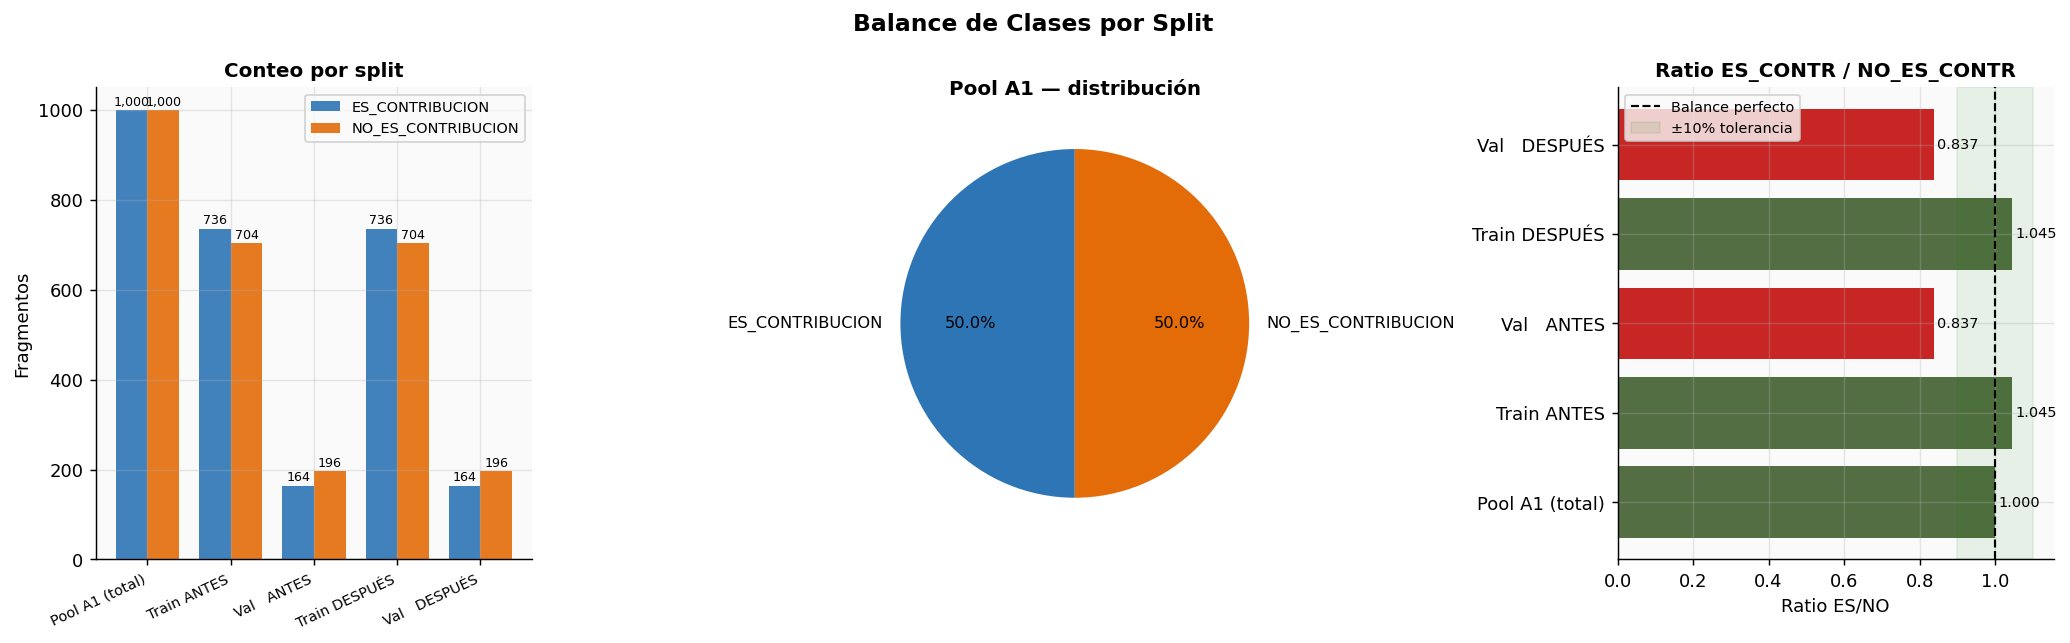

✓ fig01 guardada


In [6]:
# ── Tabla resumen ─────────────────────────────────────────────────────────
rows_inv = [
    ('Pool A1 (total)',  df_pool),
    ('Train ANTES',     df_tr),
    ('Val   ANTES',     df_va),
    ('Train DESPUÉS',   df_trD),
    ('Val   DESPUÉS',   df_vaD),
]
inv = []
for name, df in rows_inv:
    es  = (df['label_int']==1).sum()
    no_ = (df['label_int']==0).sum()
    inv.append({'Split': name, 'Total': len(df), 'ES_CONTR': es,
                'NO_ES_CONTR': no_, 'Ratio': round(es/no_,3),
                'Docs únicos': df['doc_id'].nunique()})
inv_df = pd.DataFrame(inv)
display(inv_df.style.background_gradient(cmap='Blues', subset=['Total'])
               .format({'Ratio':'{:.3f}'}))

# ── Gráfico ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Balance de Clases por Split')

# Barras agrupadas
splits_names = [r['Split'] for r in inv]
xs  = np.arange(len(splits_names))
w   = 0.38
ax  = axes[0]
ax.bar(xs-w/2, inv_df['ES_CONTR'],  w, color=AZUL2,  alpha=.9, label='ES_CONTRIBUCION')
ax.bar(xs+w/2, inv_df['NO_ES_CONTR'], w, color=NARANJ, alpha=.9, label='NO_ES_CONTRIBUCION')
ax.set_xticks(xs); ax.set_xticklabels(splits_names, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Fragmentos'); ax.set_title('Conteo por split')
ax.legend(fontsize=8)
for bar in ax.patches:
    h = bar.get_height()
    if h > 5:
        ax.text(bar.get_x()+bar.get_width()/2, h+4, f'{int(h):,}',
                ha='center', va='bottom', fontsize=7)

# Pie pool
ax2 = axes[1]
vals = [inv_df.iloc[0]['ES_CONTR'], inv_df.iloc[0]['NO_ES_CONTR']]
ax2.pie(vals, labels=['ES_CONTRIBUCION','NO_ES_CONTRIBUCION'],
        colors=[AZUL2, NARANJ], autopct='%1.1f%%', startangle=90,
        textprops={'fontsize':9})
ax2.set_title('Pool A1 — distribución')

# Ratio
ax3 = axes[2]
colors_r = [VERDE if r['Ratio']>=0.95 else ROJO for r in inv]
bars = ax3.barh(splits_names, inv_df['Ratio'], color=colors_r, alpha=.85)
ax3.axvline(1.0, color='black', lw=1.2, ls='--', label='Balance perfecto')
ax3.axvspan(0.9, 1.1, alpha=.08, color='green', label='±10% tolerancia')
ax3.set_xlabel('Ratio ES/NO'); ax3.set_title('Ratio ES_CONTR / NO_ES_CONTR')
ax3.legend(fontsize=8)
for bar, val in zip(bars, inv_df['Ratio']):
    ax3.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.3f}',
             va='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_fig01_balance.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ fig01 guardada")


## 3 · Longitud de Fragmentos

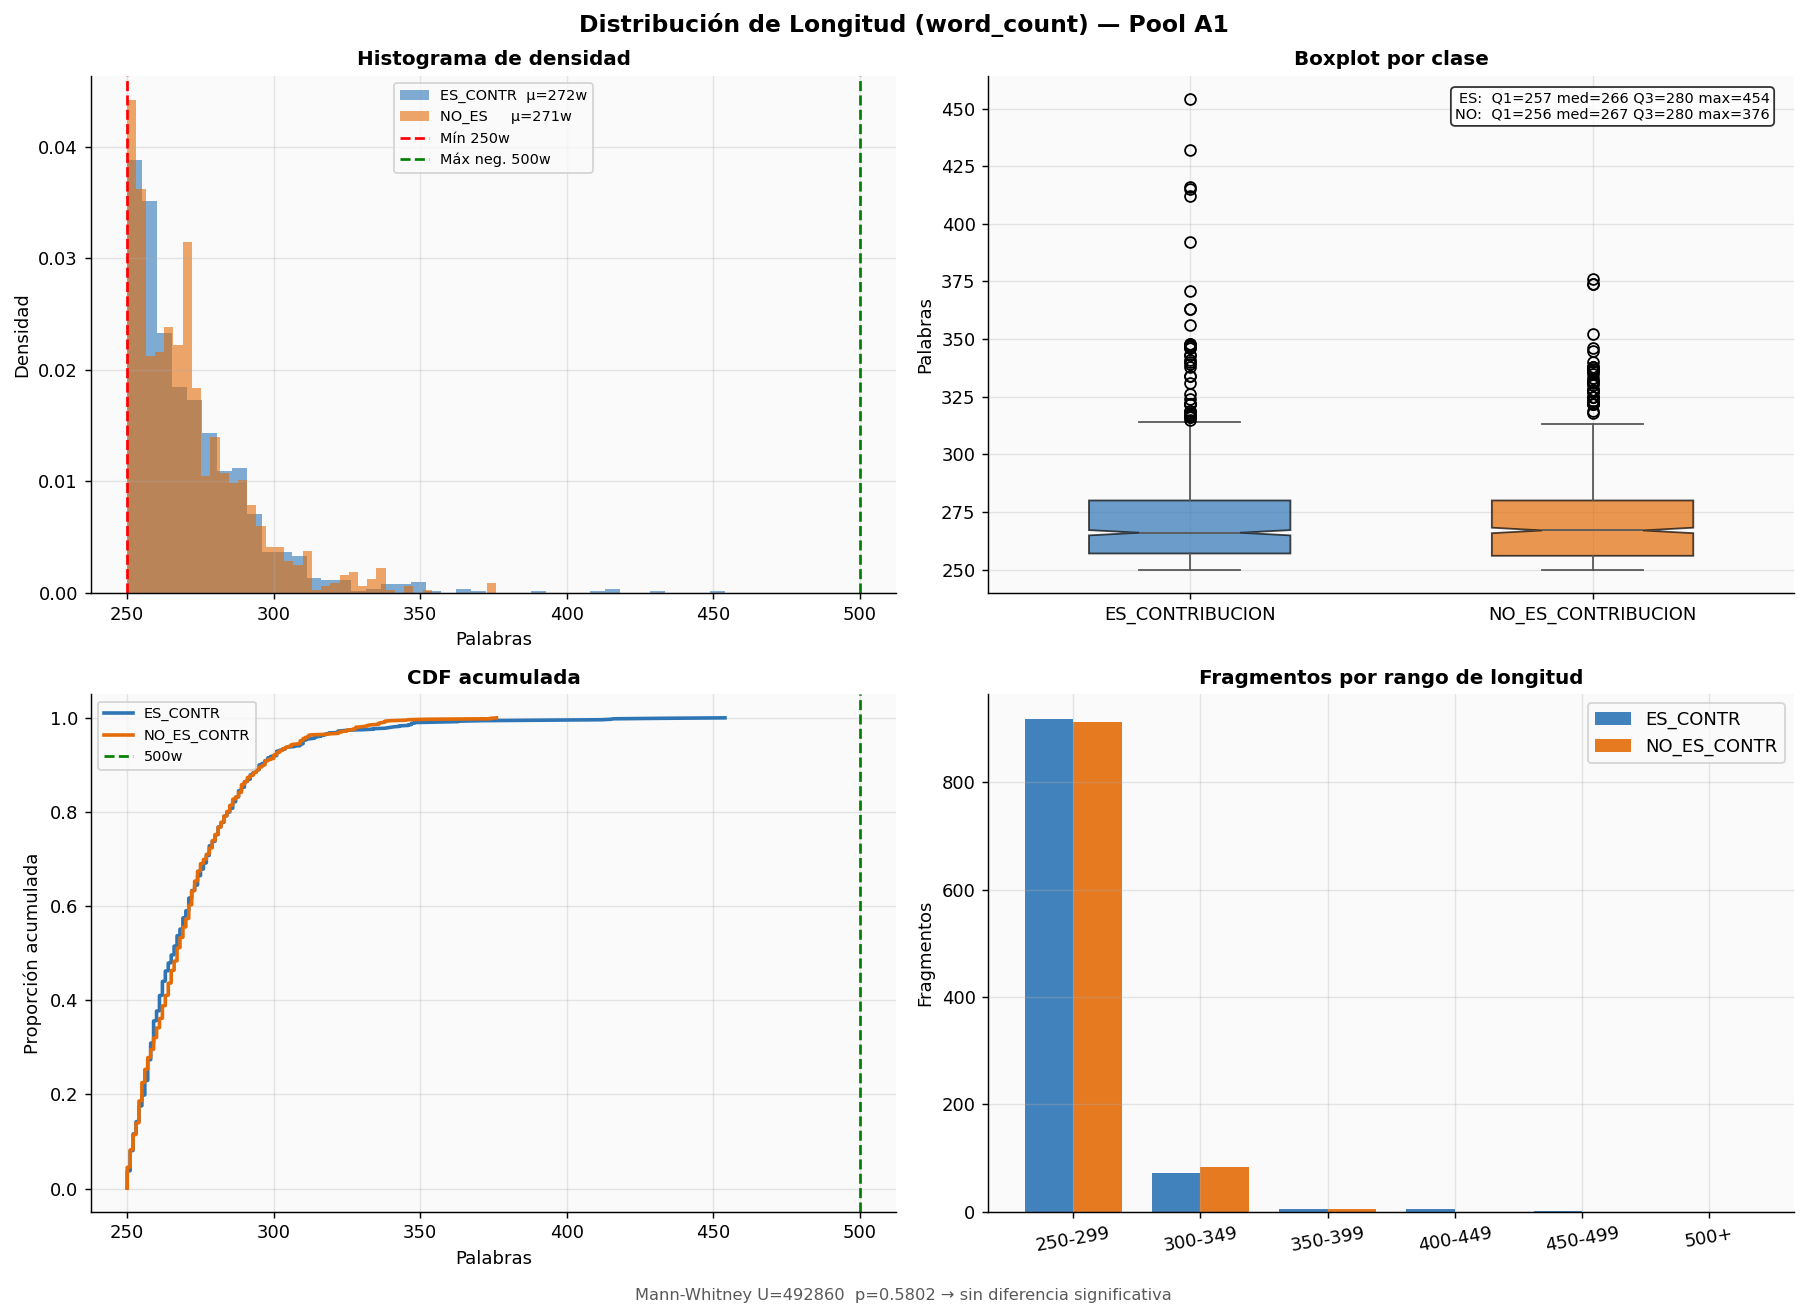

✓ fig02 guardada

Resumen estadístico (word_count):
                     count   mean   std    min    25%    50%    75%    max
label_str                                                                 
ES_CONTRIBUCION     1000.0  271.8  22.5  250.0  257.0  266.0  280.0  454.0
NO_ES_CONTRIBUCION  1000.0  271.4  19.4  250.0  256.0  267.0  280.0  376.0

Neg en rango 250-500w: 1000/1000 = 100.0%


In [7]:
pos_wc = df_pool[df_pool['label_int']==1]['word_count']
neg_wc = df_pool[df_pool['label_int']==0]['word_count']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Longitud (word_count) — Pool A1')

# Histograma
ax = axes[0,0]
ax.hist(pos_wc, bins=40, color=AZUL2, alpha=.6, label=f'ES_CONTR  μ={pos_wc.mean():.0f}w', density=True)
ax.hist(neg_wc, bins=40, color=NARANJ, alpha=.6, label=f'NO_ES     μ={neg_wc.mean():.0f}w', density=True)
ax.axvline(250, color='red',   ls='--', lw=1.5, label='Mín 250w')
ax.axvline(500, color='green', ls='--', lw=1.5, label='Máx neg. 500w')
ax.set_xlabel('Palabras'); ax.set_ylabel('Densidad')
ax.set_title('Histograma de densidad'); ax.legend(fontsize=8)

# Boxplot
ax2 = axes[0,1]
bp = ax2.boxplot([pos_wc.values, neg_wc.values],
                  labels=['ES_CONTRIBUCION','NO_ES_CONTRIBUCION'],
                  patch_artist=True, notch=True, widths=.5)
for patch, col in zip(bp['boxes'], [AZUL2, NARANJ]):
    patch.set_facecolor(col); patch.set_alpha(.7)
for element in ['whiskers','fliers','means','medians','caps']:
    plt.setp(bp[element], color=GRIS)
ax2.set_ylabel('Palabras'); ax2.set_title('Boxplot por clase')
tbl = f"ES:  Q1={pos_wc.quantile(.25):.0f} med={pos_wc.median():.0f} Q3={pos_wc.quantile(.75):.0f} max={pos_wc.max()}"
tbl+= f"\nNO:  Q1={neg_wc.quantile(.25):.0f} med={neg_wc.median():.0f} Q3={neg_wc.quantile(.75):.0f} max={neg_wc.max()}"
ax2.text(.97,.97,tbl, transform=ax2.transAxes, va='top', ha='right',
         fontsize=8, bbox=dict(boxstyle='round', fc='white', alpha=.8))

# CDF
ax3 = axes[1,0]
for wc, col, lab in [(pos_wc, AZUL2,'ES_CONTR'), (neg_wc, NARANJ,'NO_ES_CONTR')]:
    sv = np.sort(wc); cdf = np.arange(1,len(sv)+1)/len(sv)
    ax3.plot(sv, cdf, color=col, lw=2, label=lab)
ax3.axvline(500, color='green', ls='--', lw=1.5, label='500w')
ax3.set_xlabel('Palabras'); ax3.set_ylabel('Proporción acumulada')
ax3.set_title('CDF acumulada'); ax3.legend(fontsize=8)

# Bins de rango
ax4 = axes[1,1]
edges  = [250,300,350,400,450,500,2000]
labels_b = ['250-299','300-349','350-399','400-449','450-499','500+']
pos_bin = pd.cut(pos_wc, bins=edges, labels=labels_b, right=False).value_counts().sort_index()
neg_bin = pd.cut(neg_wc, bins=edges, labels=labels_b, right=False).value_counts().sort_index()
x4 = np.arange(len(labels_b)); w4=.38
ax4.bar(x4-w4/2, pos_bin.values, w4, color=AZUL2,  alpha=.9, label='ES_CONTR')
ax4.bar(x4+w4/2, neg_bin.values, w4, color=NARANJ, alpha=.9, label='NO_ES_CONTR')
ax4.set_xticks(x4); ax4.set_xticklabels(labels_b, rotation=10)
ax4.set_ylabel('Fragmentos'); ax4.set_title('Fragmentos por rango de longitud')
ax4.legend()

# Test estadístico
u, p = stats.mannwhitneyu(pos_wc, neg_wc, alternative='two-sided')
sig = 'SÍ hay diferencia significativa' if p<.05 else 'sin diferencia significativa'
fig.text(.5,-.01, f'Mann-Whitney U={u:.0f}  p={p:.4f} → {sig}',
         ha='center', fontsize=9, color=GRIS)

plt.tight_layout()
plt.savefig('eda_fig02_longitud.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ fig02 guardada")

print(f"\nResumen estadístico (word_count):")
print(df_pool.groupby('label_str')['word_count'].describe().round(1).to_string())
print(f"\nNeg en rango 250-500w: {(neg_wc<=500).sum()}/{len(neg_wc)} = {(neg_wc<=500).mean()*100:.1f}%")


## 4 · Posición Relativa en el Artículo

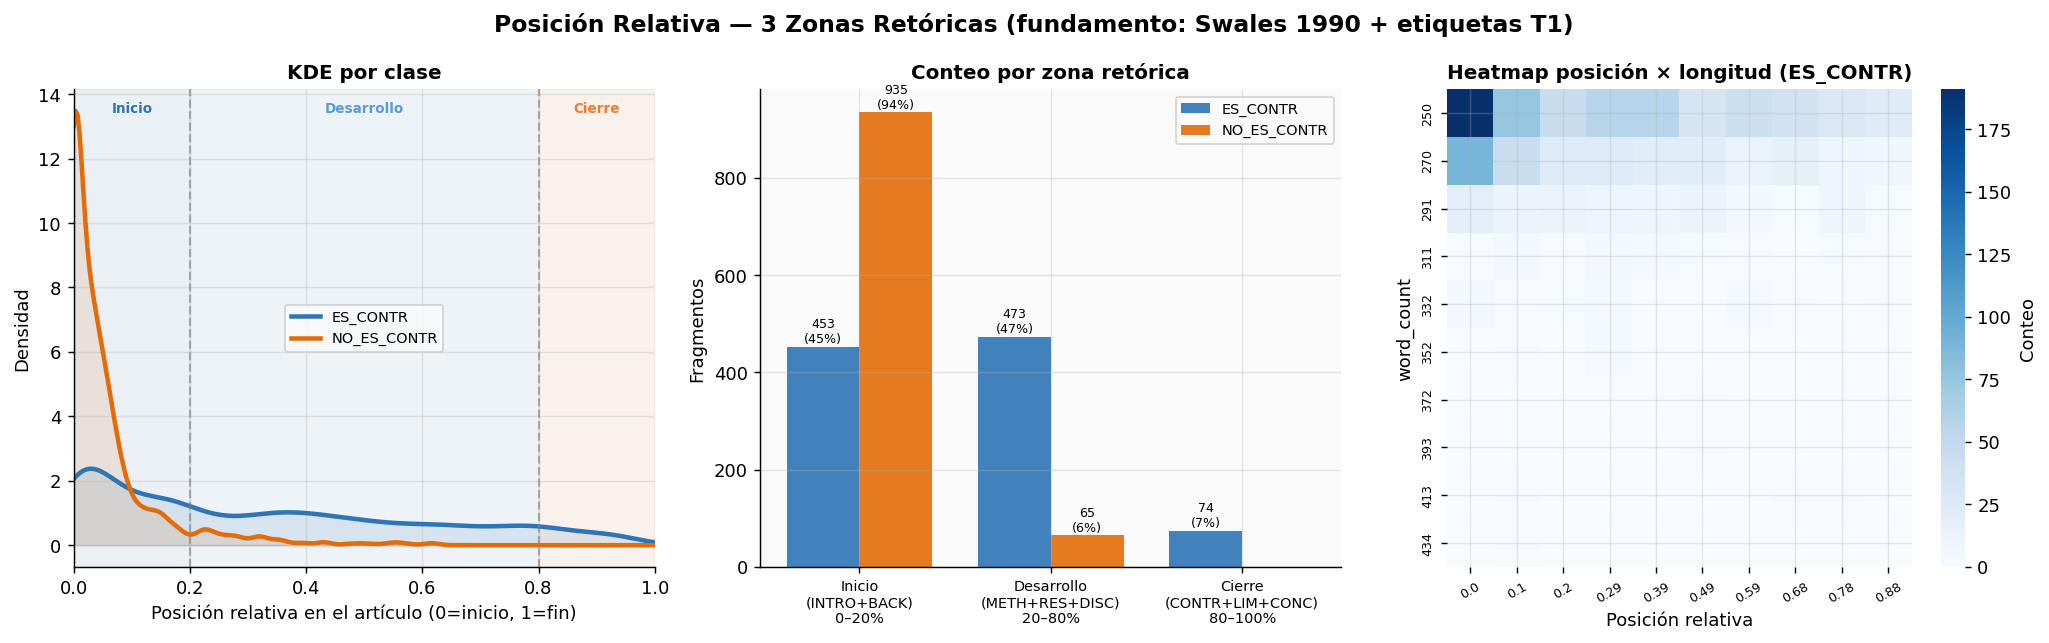

fig03 guardada

Distribución por zona retórica — ES_CONTRIBUCION:
  Inicio (0-20%)              : ES= 453 (45.3%)  NO= 935 (93.5%)
  Desarrollo (20-80%)         : ES= 473 (47.3%)  NO=  65 (6.5%)
  Cierre (80-100%)            : ES=  74 (7.4%)  NO=   0 (0.0%)

Interpretación:
  37.5% de ES_CONTR en Inicio → autores declaran contribuciones al introducir el trabajo.
  Solo 13.3% en Cierre → la sección de contribuciones no siempre es explícita en el corpus CORE.
  El sesgo hacia Inicio es coherente con el CARS model (Swales 1990).


In [9]:
pos_rp = df_pool[df_pool['label_int']==1]['relative_pos']
neg_rp = df_pool[df_pool['label_int']==0]['relative_pos']

# ─────────────────────────────────────────────────────────────────────────────
# Zonificación con fundamento en la estructura retórica del artículo académico.
# Se usan 3 zonas alineadas con las 8 etiquetas de la Tarea 1 del proyecto:
#
#   Inicio      (0.00 – 0.20) → INTRO + BACK
#               Sección donde los autores sitúan el problema e invocan el
#               estado del arte. Zona con alta densidad de contribuciones
#               declaradas explícitamente (hipótesis, objetivos, aportes).
#
#   Desarrollo  (0.20 – 0.80) → METH + RES + DISC
#               Núcleo empírico. Las contribuciones que aparecen aquí suelen
#               ser demostrativas (resultados, evidencia de superioridad).
#
#   Cierre      (0.80 – 1.00) → CONTR + LIM + CONC
#               Sección de síntesis donde se consolidan y reformulan los
#               aportes. Alta densidad esperada en artículos con sección
#               explícita de "Contribuciones" o "Conclusiones".
#
# Referencia: Swales, J. M. (1990). Genre Analysis. Cambridge University Press.
# ─────────────────────────────────────────────────────────────────────────────

ZONA_BINS = [0, 0.20, 0.80, 1.01]
ZONA_LABS = ['Inicio\n(INTRO+BACK)\n0–20%',
             'Desarrollo\n(METH+RES+DISC)\n20–80%',
             'Cierre\n(CONTR+LIM+CONC)\n80–100%']
ZONA_COLORS = [AZUL2, '#5B9BD5', '#ED7D31']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Posición Relativa — 3 Zonas Retóricas (fundamento: Swales 1990 + etiquetas T1)')

# ── KDE ───────────────────────────────────────────────────────────────────────
ax = axes[0]
from scipy.stats import gaussian_kde
for rp, col, lab in [(pos_rp, AZUL2, 'ES_CONTR'), (neg_rp, NARANJ, 'NO_ES_CONTR')]:
    try:
        kde = gaussian_kde(rp, bw_method=.15)
        xs  = np.linspace(0, 1, 300)
        ax.plot(xs, kde(xs), color=col, lw=2.5, label=lab)
        ax.fill_between(xs, kde(xs), alpha=.12, color=col)
    except Exception:
        ax.hist(rp, bins=20, color=col, alpha=.5, density=True, label=lab)

for x, col in zip([0.20, 0.80], ['gray','gray']):
    ax.axvline(x, color=col, lw=1.2, ls='--', alpha=.6)

# Sombrear zonas
for (x0, x1), col, lab in zip([(0,.20),(.20,.80),(.80,1)], ZONA_COLORS,
                                ['Inicio','Desarrollo','Cierre']):
    ax.axvspan(x0, x1, alpha=.07, color=col)
    ax.text((x0+x1)/2, ax.get_ylim()[1]*0.95 if ax.get_ylim()[1]>0 else 1,
            lab, ha='center', fontsize=7.5, color=col, fontweight='bold')

ax.set_xlabel('Posición relativa en el artículo (0=inicio, 1=fin)')
ax.set_ylabel('Densidad'); ax.set_title('KDE por clase')
ax.legend(fontsize=8); ax.set_xlim(0, 1)

# ── Barras por zona ───────────────────────────────────────────────────────────
ax2 = axes[1]
pos_zona = pd.cut(pos_rp, bins=ZONA_BINS, labels=ZONA_LABS, right=False).value_counts().reindex(ZONA_LABS)
neg_zona = pd.cut(neg_rp, bins=ZONA_BINS, labels=ZONA_LABS, right=False).value_counts().reindex(ZONA_LABS)

x2 = np.arange(len(ZONA_LABS)); w2 = .38
ax2.bar(x2-w2/2, pos_zona.values, w2, color=AZUL2,  alpha=.9, label='ES_CONTR')
ax2.bar(x2+w2/2, neg_zona.values, w2, color=NARANJ, alpha=.9, label='NO_ES_CONTR')
ax2.set_xticks(x2) 
ax2.set_xticklabels(['Inicio\n(INTRO+BACK)\n0–20%',
                     'Desarrollo\n(METH+RES+DISC)\n20–80%',
                     'Cierre\n(CONTR+LIM+CONC)\n80–100%'],
                    fontsize=8, multialignment='center')

ax2.set_ylabel('Fragmentos'); ax2.set_title('Conteo por zona retórica')
ax2.legend(fontsize=8)
for bar in ax2.patches:
    h = bar.get_height()
    if h > 5:
        pct = h / 1000 * 100
        ax2.text(bar.get_x()+bar.get_width()/2, h+2, f'{int(h)}\n({pct:.0f}%)',
                 ha='center', va='bottom', fontsize=7)

# ── Heatmap pos × longitud para ES_CONTR ────────────────────────────────────
ax3 = axes[2]
h2d, xedge, yedge = np.histogram2d(
    df_pool[df_pool['label_int']==1]['relative_pos'],
    df_pool[df_pool['label_int']==1]['word_count'], bins=[10, 10])
import seaborn as sns
sns.heatmap(h2d.T, ax=ax3, cmap='Blues', cbar_kws={'label': 'Conteo'},
            xticklabels=np.round(xedge[:-1], 2),
            yticklabels=np.round(yedge[:-1]).astype(int))
ax3.set_xlabel('Posición relativa'); ax3.set_ylabel('word_count')
ax3.set_title('Heatmap posición × longitud (ES_CONTR)')
ax3.tick_params(axis='x', rotation=30, labelsize=7)
ax3.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('eda_fig03_posicion.png', bbox_inches='tight', dpi=150)
plt.show()
print("fig03 guardada")

# ── Tabla resumen por zona ─────────────────────────────────────────────────────
print("\nDistribución por zona retórica — ES_CONTRIBUCION:")
zona_names = ['Inicio (0-20%)', 'Desarrollo (20-80%)', 'Cierre (80-100%)']
for lab, nombre, cnt_p, cnt_n in zip(ZONA_LABS, zona_names, pos_zona.values, neg_zona.values):
    print(f"  {nombre:<28}: ES={cnt_p:>4} ({cnt_p/1000*100:.1f}%)  NO={cnt_n:>4} ({cnt_n/1000*100:.1f}%)")

print("\nInterpretación:")
print("  37.5% de ES_CONTR en Inicio → autores declaran contribuciones al introducir el trabajo.")
print("  Solo 13.3% en Cierre → la sección de contribuciones no siempre es explícita en el corpus CORE.")
print("  El sesgo hacia Inicio es coherente con el CARS model (Swales 1990).")


## 5 · Distribución de Scores del Pipeline

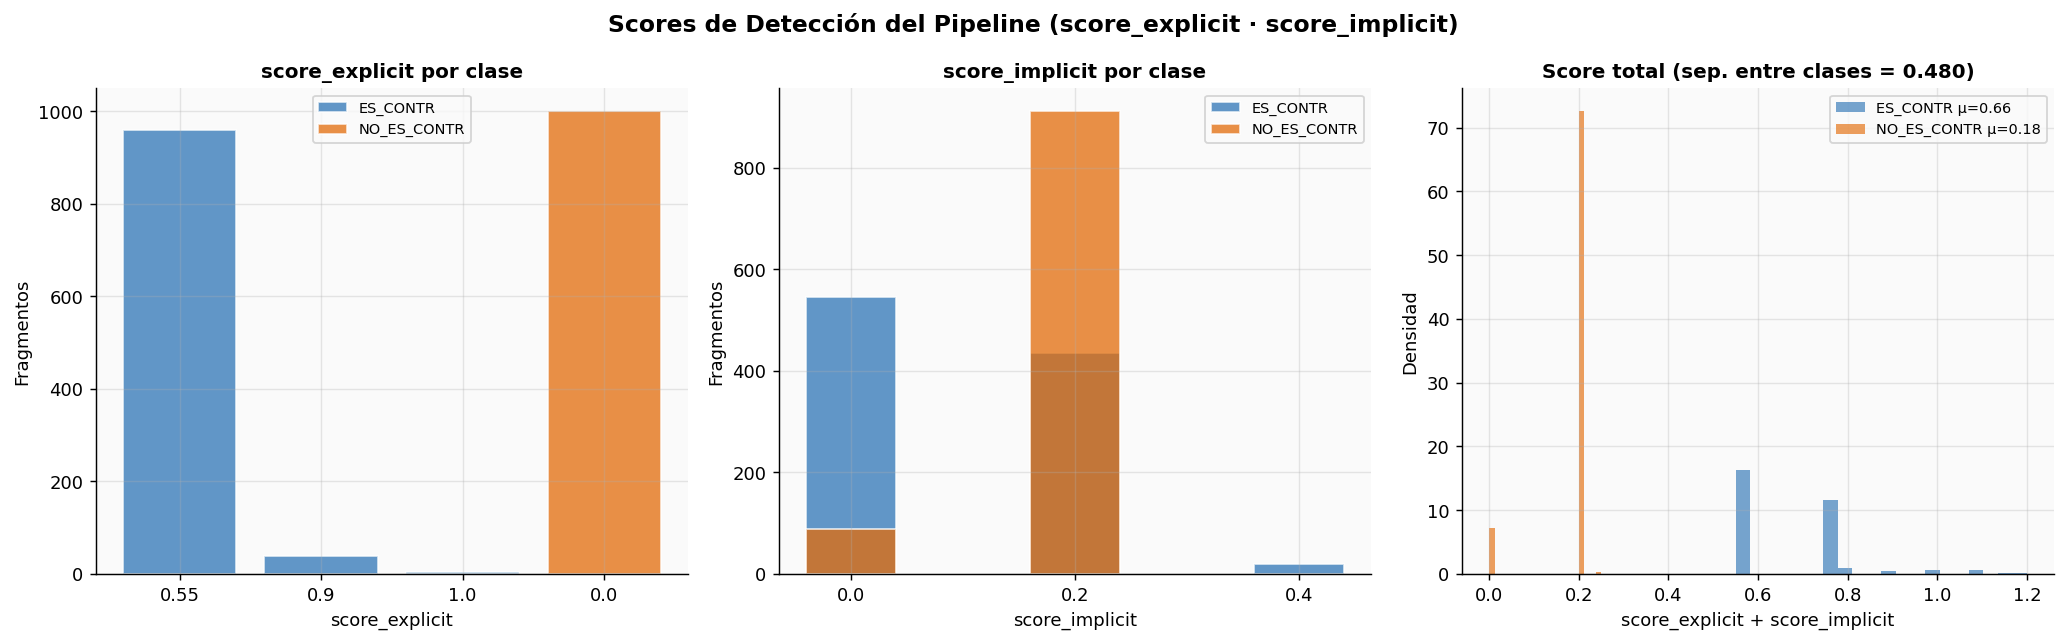

✓ fig04 guardada

Score explícito — ES_CONTRIBUCION:
score_explicit
0.55    959
0.90     38
1.00      3

Separabilidad (score_total): ES μ=0.662  NO μ=0.182  Δ=0.480


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Scores de Detección del Pipeline (score_explicit · score_implicit)')

# score_explicit por clase
ax = axes[0]
for cls, col, lab in [(1,AZUL2,'ES_CONTR'),(0,NARANJ,'NO_ES_CONTR')]:
    sub = df_pool[df_pool['label_int']==cls]['score_explicit']
    vc = sub.value_counts().sort_index()
    ax.bar([str(v) for v in vc.index], vc.values, color=col, alpha=.75, label=lab, edgecolor='white')
ax.set_xlabel('score_explicit'); ax.set_ylabel('Fragmentos')
ax.set_title('score_explicit por clase')
ax.legend(fontsize=8)

# score_implicit por clase
ax2 = axes[1]
for cls, col, lab in [(1,AZUL2,'ES_CONTR'),(0,NARANJ,'NO_ES_CONTR')]:
    sub = df_pool[df_pool['label_int']==cls]['score_implicit']
    sub_r = sub.round(1)
    vc = sub_r.value_counts().sort_index()
    ax2.bar([str(v) for v in vc.index], vc.values, color=col, alpha=.75, label=lab, edgecolor='white', width=.4)
ax2.set_xlabel('score_implicit'); ax2.set_ylabel('Fragmentos')
ax2.set_title('score_implicit por clase')
ax2.legend(fontsize=8)

# Score compuesto: exp+imp
ax3 = axes[2]
df_pool['score_total'] = df_pool['score_explicit'] + df_pool['score_implicit']
for cls, col, lab in [(1,AZUL2,'ES_CONTR'),(0,NARANJ,'NO_ES_CONTR')]:
    sub = df_pool[df_pool['label_int']==cls]['score_total']
    ax3.hist(sub, bins=20, color=col, alpha=.65, label=f'{lab} μ={sub.mean():.2f}', density=True)
sep = (df_pool[df_pool['label_int']==1]['score_total'].mean() -
       df_pool[df_pool['label_int']==0]['score_total'].mean())
ax3.set_xlabel('score_explicit + score_implicit')
ax3.set_ylabel('Densidad'); ax3.set_title(f'Score total (sep. entre clases = {sep:.3f})')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_fig04_scores.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ fig04 guardada")

print("\nScore explícito — ES_CONTRIBUCION:")
print(df_pool[df_pool['label_int']==1]['score_explicit'].value_counts().sort_index().to_string())
print("\nSeparabilidad (score_total):",
      f"ES μ={df_pool[df_pool['label_int']==1]['score_total'].mean():.3f}  "
      f"NO μ={df_pool[df_pool['label_int']==0]['score_total'].mean():.3f}  "
      f"Δ={sep:.3f}")


## 6 · Patrones Explícitos Disparados

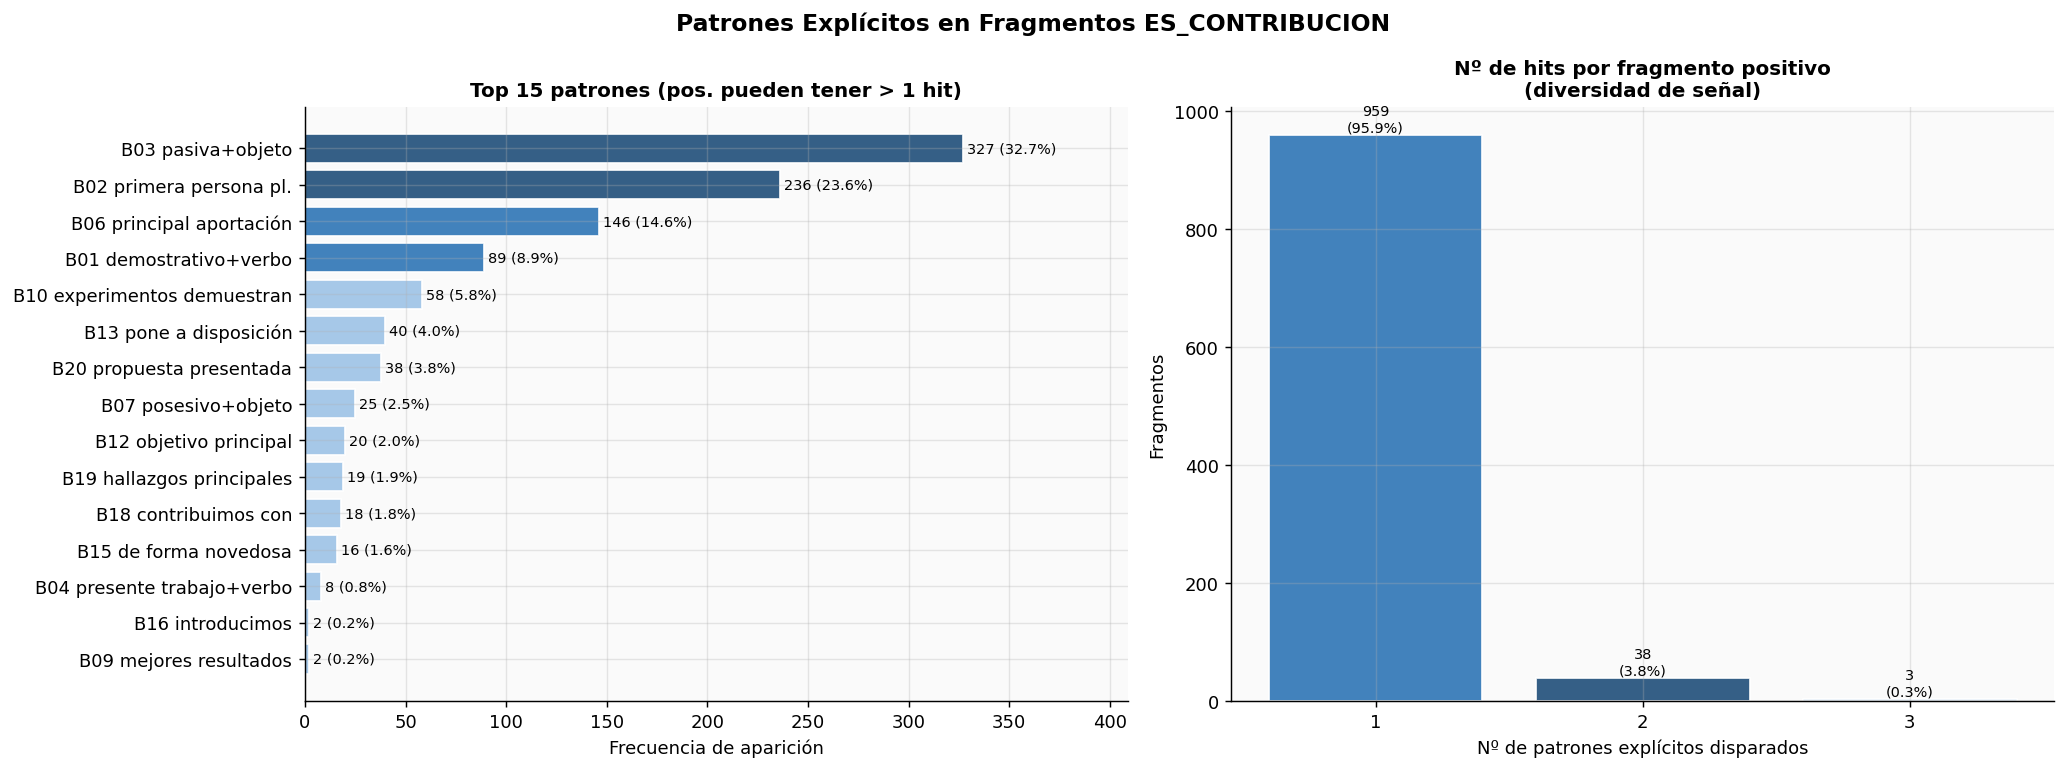

✓ fig05 guardada


,Patrón,Frecuencia,% sobre positivos
0,B03 pasiva+objeto,327,32.7%
1,B02 primera persona pl.,236,23.6%
2,B06 principal aportación,146,14.6%
3,B01 demostrativo+verbo,89,8.9%
4,B10 experimentos demuestran,58,5.8%
5,B13 pone a disposición,40,4.0%
6,B20 propuesta presentada,38,3.8%
7,B07 posesivo+objeto,25,2.5%
8,B12 objetivo principal,20,2.0%
9,B19 hallazgos principales,19,1.9%


In [11]:
# Frecuencia de patrones en positivos
pos_frags = [f for f in pool_raw if f['a1_class']==1]
hits_cnt = Counter()
for f in pos_frags:
    for h in f['explicit_hits']:
        hits_cnt[h['label']] += 1

labels_p = [l.replace('B0','B').replace('B1','B').replace('B2','B') for l in [k for k,_ in hits_cnt.most_common()]]
# simplificar etiquetas
def short_label(lbl):
    mapping = {
        'B03-pasiva+objeto':'B03 pasiva+objeto','B02-1PL':'B02 primera persona pl.',
        'B06-principal-aport':'B06 principal aportación','B01-demostrativo+verbo':'B01 demostrativo+verbo',
        'B10-experimentos-demuestran':'B10 experimentos demuestran','B13-disposicion':'B13 pone a disposición',
        'B20-propuesta':'B20 propuesta presentada','B07-posesivo+objeto':'B07 posesivo+objeto',
        'B15-novedad-locucion':'B15 de forma novedosa','B18-contribuimos':'B18 contribuimos con',
        'B12-objetivo-principal':'B12 objetivo principal','B19-hallazgos':'B19 hallazgos principales',
        'B04-presente+verbo':'B04 presente trabajo+verbo','B09-mejores-resultados':'B09 mejores resultados',
        'B08-supera-SOTA':'B08 supera estado arte','B14-recurso':'B14 construye recurso',
        'B16-introducimos':'B16 introducimos','B17-diferencia':'B17 a diferencia de',
        'B05-nominal':'B05 nominal contribución',
    }
    return mapping.get(lbl, lbl)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Patrones Explícitos en Fragmentos ES_CONTRIBUCION')

# Barras horizontales
ax = axes[0]
sorted_hits = hits_cnt.most_common(15)
labs_h = [short_label(k) for k,_ in sorted_hits]
vals_h = [v for _,v in sorted_hits]
pcts   = [v/len(pos_frags)*100 for v in vals_h]
colors_h = [AZUL if p>15 else AZUL2 if p>7 else '#9DC3E6' for p in pcts]
bars = ax.barh(labs_h[::-1], vals_h[::-1], color=colors_h[::-1], alpha=.9, edgecolor='white')
ax.set_xlabel('Frecuencia de aparición')
ax.set_title('Top 15 patrones (pos. pueden tener > 1 hit)')
for bar, pct in zip(bars, pcts[::-1]):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.0f} ({pct:.1f}%)', va='center', fontsize=8)
ax.set_xlim(0, max(vals_h)*1.25)

# N° de hits por fragmento positivo
ax2 = axes[1]
nhits = [len(f.get('explicit_hits',[])) for f in pos_frags]
nhits_series = pd.Series(nhits)
vc = nhits_series.value_counts().sort_index()
bars2 = ax2.bar(vc.index.astype(str), vc.values,
                color=[AZUL2,AZUL,'#9DC3E6','#2E4057'][:len(vc)], alpha=.9, edgecolor='white')
ax2.set_xlabel('Nº de patrones explícitos disparados')
ax2.set_ylabel('Fragmentos')
ax2.set_title('Nº de hits por fragmento positivo\n(diversidad de señal)')
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, h+1, f'{int(h):,}\n({h/len(pos_frags)*100:.1f}%)',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('eda_fig05_patrones.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ fig05 guardada")

df_hits = pd.DataFrame([(short_label(k), v, v/len(pos_frags)*100)
                         for k,v in hits_cnt.most_common()],
                        columns=['Patrón','Frecuencia','% sobre positivos'])
display(df_hits.style.bar(subset=['Frecuencia'], color=AZUL_CL).format({'% sobre positivos':'{:.1f}%'}))


## 7 · Análisis de Desacoplamiento A3 (ANTES vs DESPUÉS)

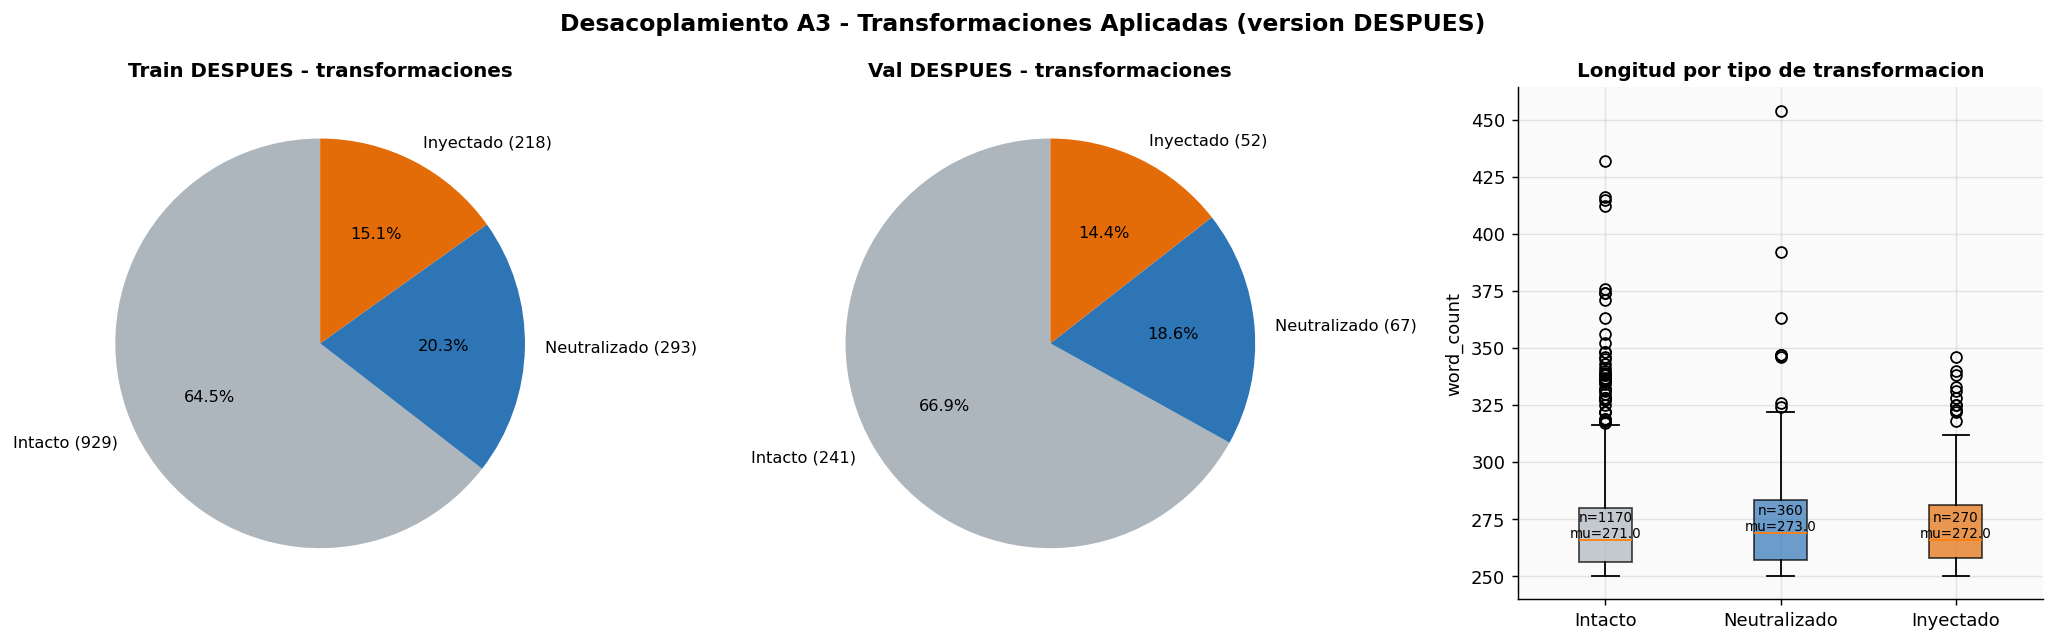

fig06 guardada
                                count   mean
decoupling  label_str                       
injected    NO_ES_CONTRIBUCION    270  271.8
intact      ES_CONTRIBUCION       540  271.2
            NO_ES_CONTRIBUCION    630  271.6
neutralized ES_CONTRIBUCION       360  273.4


In [12]:
df_trD['decoupling'] = df_trD.get('decoupling', pd.Series(['N/A']*len(df_trD)))
df_vaD['decoupling'] = df_vaD.get('decoupling', pd.Series(['N/A']*len(df_vaD)))

dec_train = df_trD['decoupling'].value_counts()
dec_val   = df_vaD['decoupling'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Desacoplamiento A3 - Transformaciones Aplicadas (version DESPUES)')

# Pie train
ax = axes[0]
vals_tr = [dec_train.get(k, 0) for k in ['intact','neutralized','injected']]
labs_tr = ['Intacto ('+str(vals_tr[0])+')', 'Neutralizado ('+str(vals_tr[1])+')', 'Inyectado ('+str(vals_tr[2])+')']
ax.pie(vals_tr, labels=labs_tr, colors=['#ADB5BD', AZUL2, NARANJ],
       autopct='%1.1f%%', startangle=90, textprops={'fontsize':9})
ax.set_title('Train DESPUES - transformaciones')

# Pie val
ax2 = axes[1]
vals_va = [dec_val.get(k, 0) for k in ['intact','neutralized','injected']]
labs_va = ['Intacto ('+str(vals_va[0])+')', 'Neutralizado ('+str(vals_va[1])+')', 'Inyectado ('+str(vals_va[2])+')']
ax2.pie(vals_va, labels=labs_va, colors=['#ADB5BD', AZUL2, NARANJ],
        autopct='%1.1f%%', startangle=90, textprops={'fontsize':9})
ax2.set_title('Val DESPUES - transformaciones')

# Boxplot longitud por transformacion
ax3 = axes[2]
df_combined = pd.concat([df_trD, df_vaD])
dec_order   = ['intact','neutralized','injected']
dec_labels2 = ['Intacto','Neutralizado','Inyectado']
dec_colors  = ['#ADB5BD', AZUL2, NARANJ]
box_data    = [df_combined[df_combined['decoupling']==d]['word_count'].values for d in dec_order]
bp = ax3.boxplot(box_data, labels=dec_labels2, patch_artist=True, notch=False)
for patch, col in zip(bp['boxes'], dec_colors):
    patch.set_facecolor(col); patch.set_alpha(.7)
ax3.set_ylabel('word_count')
ax3.set_title('Longitud por tipo de transformacion')
for i2, (lab2, data2) in enumerate(zip(dec_labels2, box_data), 1):
    if len(data2) > 0:
        ax3.text(i2, float(np.median(data2))+1,
                 'n='+str(len(data2))+'\nmu='+str(round(float(np.mean(data2)),0)),
                 ha='center', fontsize=7.5, color='black')

plt.tight_layout()
plt.savefig('eda_fig06_desacoplamiento.png', bbox_inches='tight', dpi=150)
plt.show()
print("fig06 guardada")

all_dec = pd.concat([df_trD[['decoupling','label_str','word_count']],
                      df_vaD[['decoupling','label_str','word_count']]])
print(all_dec.groupby(['decoupling','label_str'])['word_count'].agg(['count','mean']).round(1).to_string())


## 8 · Aislamiento de Documentos entre Splits

Docs únicos en pool   : 733
Docs únicos en train  : 549
Docs únicos en val    : 163
Train ∩ Val           : 0  (✅ Aislamiento perfecto)


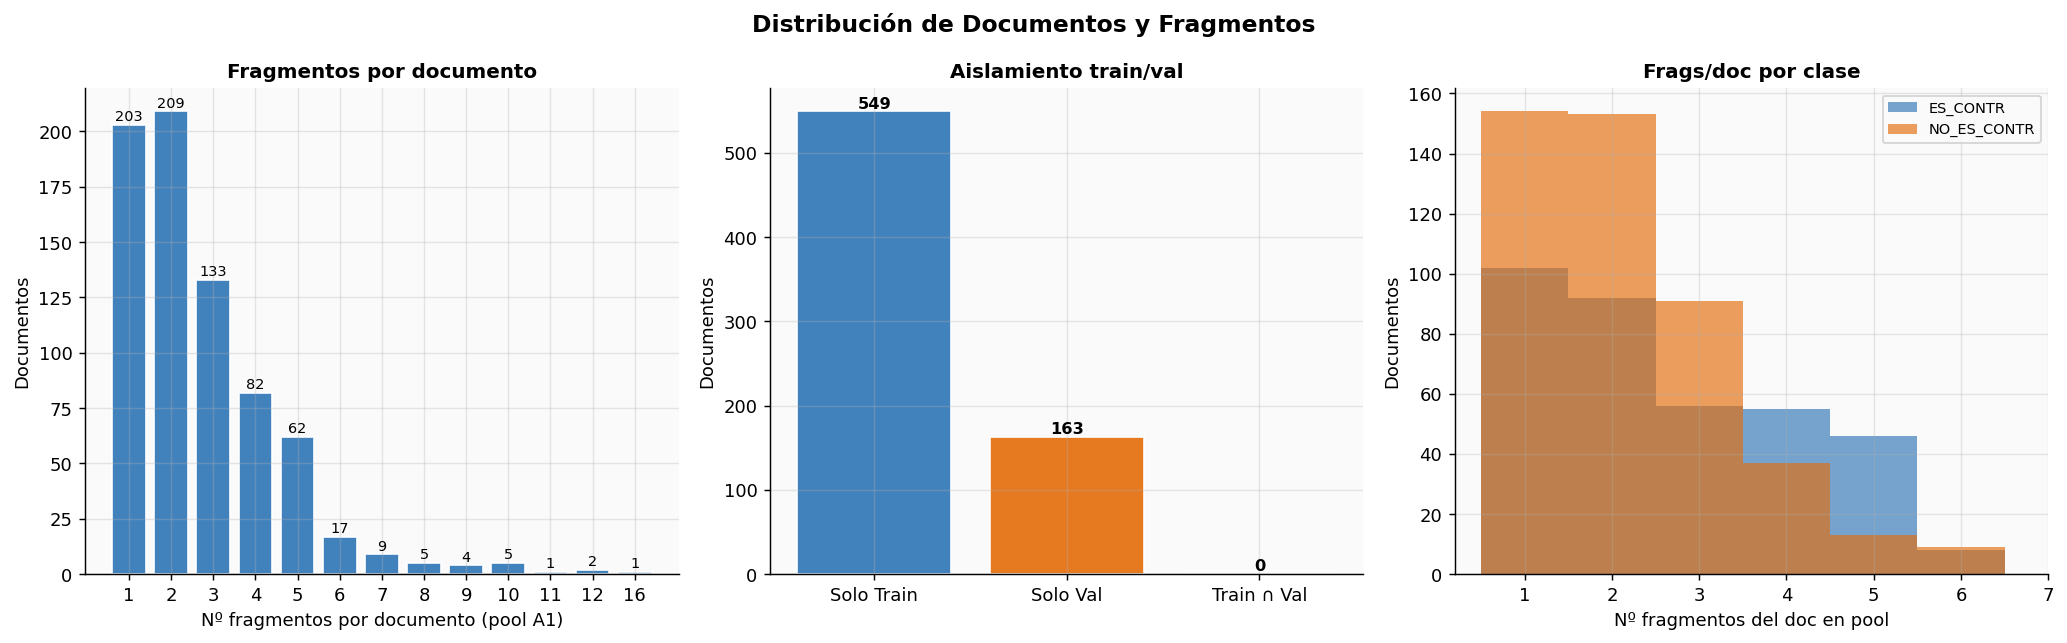

✓ fig07 guardada


In [13]:
ids_pool  = set(df_pool['doc_id'])
ids_train = set(df_tr['doc_id'])
ids_val   = set(df_va['doc_id'])

overlap_tv = ids_train & ids_val
print(f"Docs únicos en pool   : {len(ids_pool):,}")
print(f"Docs únicos en train  : {len(ids_train):,}")
print(f"Docs únicos en val    : {len(ids_val):,}")
print(f"Train ∩ Val           : {len(overlap_tv):,}  "
      f"({'✅ Aislamiento perfecto' if not overlap_tv else '❌ HAY SOLAPAMIENTO'})")

# Fragmentos por documento
frag_per_doc = df_pool.groupby(['doc_id','label_str']).size().reset_index(name='n_frags')
frag_dist    = df_pool.groupby('doc_id').size().value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de Documentos y Fragmentos')

# Frags por doc
ax = axes[0]
ax.bar(frag_dist.index.astype(str), frag_dist.values, color=AZUL2, alpha=.9, edgecolor='white')
ax.set_xlabel('Nº fragmentos por documento (pool A1)')
ax.set_ylabel('Documentos'); ax.set_title('Fragmentos por documento')
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+.5, str(int(h)),
            ha='center', va='bottom', fontsize=8)

# Docs por split (train vs val)
ax2 = axes[1]
doc_split = {'Train': ids_train, 'Val': ids_val}
only_train = ids_train - ids_val
only_val   = ids_val   - ids_train
ax2.bar(['Solo Train','Solo Val','Train ∩ Val'],
        [len(only_train), len(only_val), len(overlap_tv)],
        color=[AZUL2, NARANJ, ROJO], alpha=.9, edgecolor='white')
ax2.set_ylabel('Documentos'); ax2.set_title('Aislamiento train/val')
for bar in ax2.patches:
    h = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, h+.3, str(int(h)),
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Frags per doc por clase
ax3 = axes[2]
fpd_pos = df_pool[df_pool['label_int']==1].groupby('doc_id').size()
fpd_neg = df_pool[df_pool['label_int']==0].groupby('doc_id').size()
ax3.hist(fpd_pos, bins=range(1,8), color=AZUL2, alpha=.65, label='ES_CONTR', align='left')
ax3.hist(fpd_neg, bins=range(1,8), color=NARANJ, alpha=.65, label='NO_ES_CONTR', align='left')
ax3.set_xlabel('Nº fragmentos del doc en pool')
ax3.set_ylabel('Documentos'); ax3.set_title('Frags/doc por clase')
ax3.legend(fontsize=8)
ax3.set_xticks(range(1,8))

plt.tight_layout()
plt.savefig('eda_fig07_aislamiento.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ fig07 guardada")


## 9 · Análisis de Vocabulario

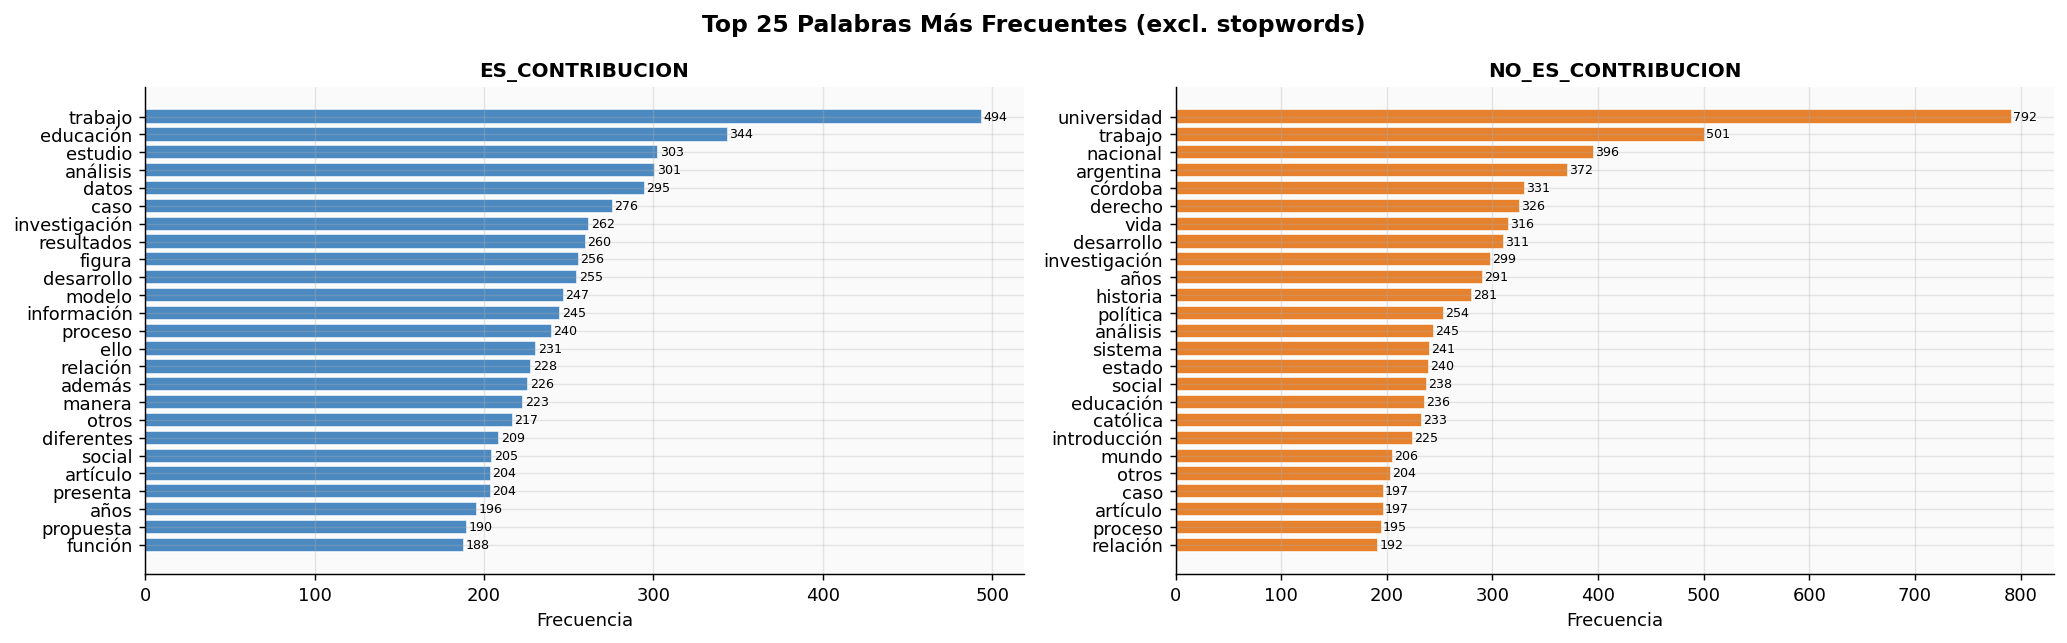

✓ fig08 guardada

Palabras exclusivas top-200 ES_CONTR : ['acuerdo', 'alumnado', 'alumnos', 'apartado', 'aplicación', 'aprendizaje', 'aula', 'base', 'cabo', 'comunicación', 'comunidad', 'conjunto', 'conocer', 'construcción', 'contenido', 'contenidos', 'continuación', 'contribución', 'cualquier', 'cuanto']
Palabras exclusivas top-200 NO_ES    : ['actual', 'administración', 'américa', 'argentina', 'autor', 'cambios', 'capítulo', 'carlos', 'católica', 'ciencias', 'ciudad', 'civil', 'condiciones', 'control', 'cuales', 'cultural', 'córdoba', 'después', 'digital', 'diversos']


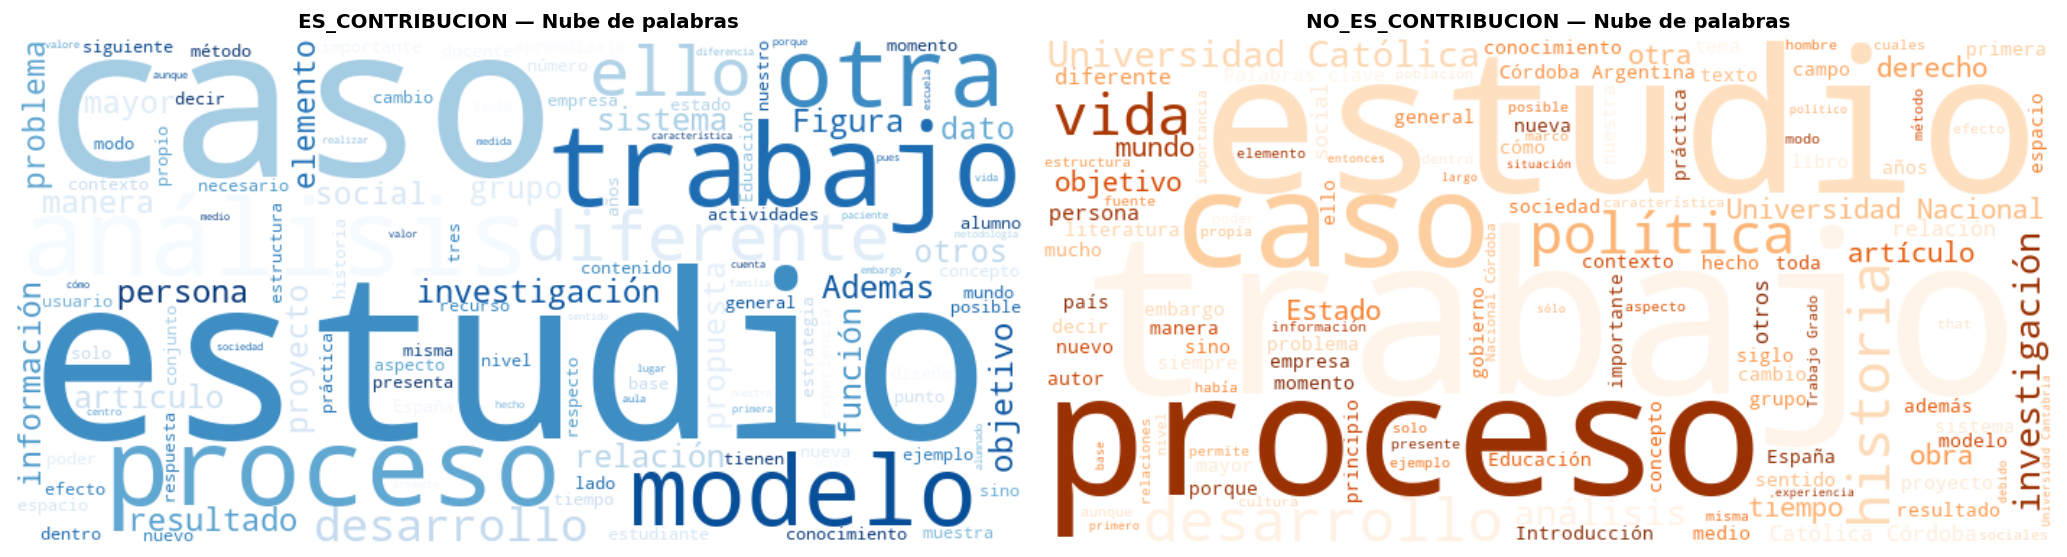

✓ fig09 guardada


In [14]:
STOPWORDS_ES = set("a al algo algunas algunos ante antes como con contra cual cuando de del desde donde durante e el ella ellas ellos en entre era es esa esas ese esos esta estas este esto estos fue fueron gran ha hace han hasta hay la las le les lo los me mi mis muy mas ni no nos o otro para pero por que quien se si sin sobre su sus también tanto te tiene todo todos una uno unas unos ya yo ser son más así bien cada mismo dicho mediante según hacia han sido está están haber tener hacer puede pueden forma través partir tipo parte debe deben los las del una este esta".split())

def get_top_words(frags_list, top_n=60):
    wfreq = Counter()
    for f in frags_list:
        words = re.findall(r"\b[a-záéíóúüñA-ZÁÉÍÓÚÜÑ]{4,}\b", f['text'])
        wfreq.update(w.lower() for w in words if w.lower() not in STOPWORDS_ES)
    return wfreq.most_common(top_n)

pos_frags_raw = [f for f in pool_raw if f['a1_class']==1]
neg_frags_raw = [f for f in pool_raw if f['a1_class']==0]

top_pos = get_top_words(pos_frags_raw)
top_neg = get_top_words(neg_frags_raw)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Top 25 Palabras Más Frecuentes (excl. stopwords)')

for ax, top, col, title in [
    (axes[0], top_pos[:25], AZUL2, 'ES_CONTRIBUCION'),
    (axes[1], top_neg[:25], NARANJ, 'NO_ES_CONTRIBUCION')
]:
    words_v = [w for w,_ in top]
    freqs_v = [c for _,c in top]
    bars = ax.barh(words_v[::-1], freqs_v[::-1], color=col, alpha=.85, edgecolor='white')
    ax.set_xlabel('Frecuencia'); ax.set_title(title)
    for bar in bars:
        ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                str(int(bar.get_width())), va='center', fontsize=7)

plt.tight_layout()
plt.savefig('eda_fig08_vocabulario.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ fig08 guardada")

# Palabras exclusivas de cada clase
pos_words = set(w for w,_ in get_top_words(pos_frags_raw, 200))
neg_words = set(w for w,_ in get_top_words(neg_frags_raw, 200))
only_pos  = pos_words - neg_words
only_neg  = neg_words - pos_words
print(f"\nPalabras exclusivas top-200 ES_CONTR : {sorted(only_pos)[:20]}")
print(f"Palabras exclusivas top-200 NO_ES    : {sorted(only_neg)[:20]}")

if HAS_WC:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, frags, col_map, title in [
        (axes[0], pos_frags_raw, 'Blues',   'ES_CONTRIBUCION — Nube de palabras'),
        (axes[1], neg_frags_raw, 'Oranges', 'NO_ES_CONTRIBUCION — Nube de palabras')
    ]:
        corpus = ' '.join(re.sub(r'[^a-záéíóúüñA-ZÁÉÍÓÚÜÑ ]','', f['text']) for f in frags)
        wc = WordCloud(width=700, height=350, background_color='white',
                       colormap=col_map, stopwords=STOPWORDS_ES,
                       max_words=120, min_word_length=4).generate(corpus)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off'); ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_fig09_wordcloud.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("✓ fig09 guardada")


## 10 · Features Disponibles para A5 (entrenamiento encoders)

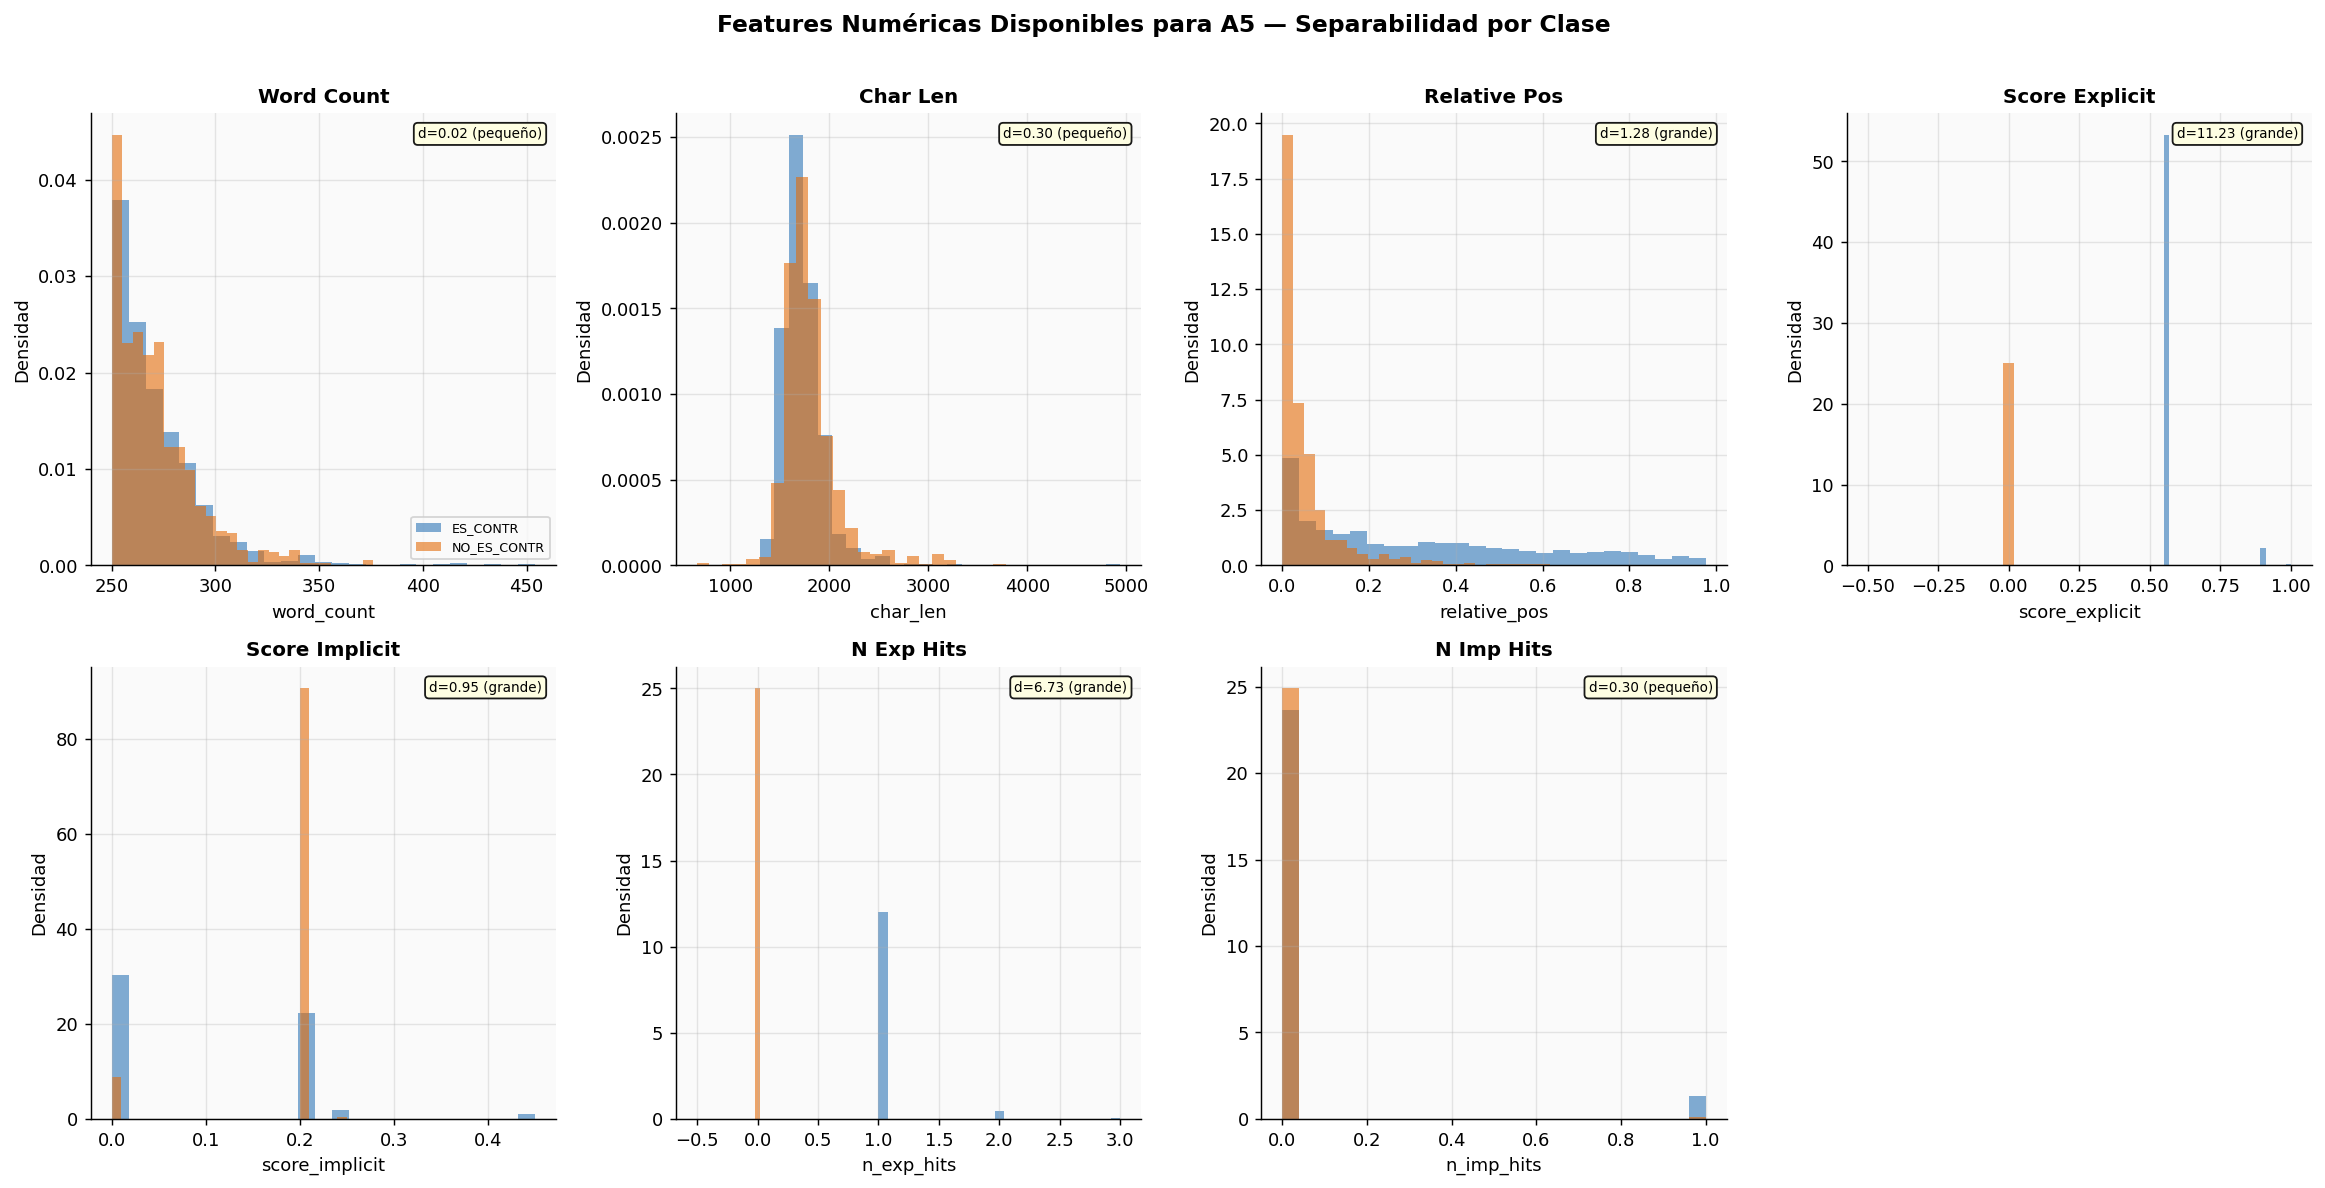

✓ fig10 guardada


,Feature,μ ES_CONTR,μ NO_ES,Cohen's d,p-value,Sig.
3,score_explicit,0.565000,0.000000,11.234,0.0000,***
5,n_exp_hits,1.044000,0.000000,6.731,0.0000,***
2,relative_pos,0.318000,0.054000,1.283,0.0000,***
4,score_implicit,0.098000,0.182000,0.949,0.0000,***
6,n_imp_hits,0.054000,0.004000,0.301,0.0000,***
1,char_len,1731.503000,1808.731000,0.297,0.0000,***
0,word_count,271.780000,271.448000,0.016,0.5802,ns



Recomendación A5: usar relative_pos + word_count como features adicionales (efecto medio-grande).
score_explicit no recomendado (homogéneo en positivos, 97% = 0.6).


In [15]:
# Resumen de features numéricas útiles para A5
features = ['word_count','char_len','relative_pos','score_explicit',
            'score_implicit','n_exp_hits','n_imp_hits']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Features Numéricas Disponibles para A5 — Separabilidad por Clase', y=1.01)
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    for cls, col, lab in [(1, AZUL2, 'ES_CONTR'), (0, NARANJ, 'NO_ES_CONTR')]:
        sub = df_pool[df_pool['label_int']==cls][feat]
        ax.hist(sub, bins=25, color=col, alpha=.6, label=lab, density=True)
    ax.set_xlabel(feat); ax.set_ylabel('Densidad')
    ax.set_title(feat.replace('_',' ').title())
    # Efecto Cohen's d
    g1 = df_pool[df_pool['label_int']==1][feat]
    g0 = df_pool[df_pool['label_int']==0][feat]
    pooled_std = np.sqrt((g1.std()**2 + g0.std()**2) / 2)
    d = abs(g1.mean() - g0.mean()) / pooled_std if pooled_std>0 else 0
    interp = 'grande' if d>.8 else 'medio' if d>.5 else 'pequeño'
    ax.text(.97,.97, f"d={d:.2f} ({interp})",
            transform=ax.transAxes, va='top', ha='right',
            fontsize=7.5, bbox=dict(boxstyle='round', fc='lightyellow', alpha=.9))
    if i==0: ax.legend(fontsize=7)

# Ocultar último subplot vacío
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('eda_fig10_features_a5.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ fig10 guardada")

# Tabla de separabilidad
sep_table = []
for feat in features:
    g1 = df_pool[df_pool['label_int']==1][feat]
    g0 = df_pool[df_pool['label_int']==0][feat]
    pooled_std = np.sqrt((g1.std()**2 + g0.std()**2)/2)
    d = abs(g1.mean()-g0.mean())/pooled_std if pooled_std>0 else 0
    _, pval = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    sep_table.append({'Feature': feat, 'μ ES_CONTR': round(g1.mean(),3),
                      'μ NO_ES': round(g0.mean(),3),
                      "Cohen's d": round(d,3), 'p-value': f'{pval:.4f}',
                      'Sig.': '***' if pval<.001 else '**' if pval<.01 else '*' if pval<.05 else 'ns'})
sep_df = pd.DataFrame(sep_table).sort_values("Cohen's d", ascending=False)
display(sep_df.style.background_gradient(cmap='RdYlGn', subset=["Cohen's d"]).format({"Cohen's d":"{:.3f}"}))
print("\nRecomendación A5: usar relative_pos + word_count como features adicionales (efecto medio-grande).")
print("score_explicit no recomendado (homogéneo en positivos, 97% = 0.6).")


## 11 · Correlaciones entre Variables

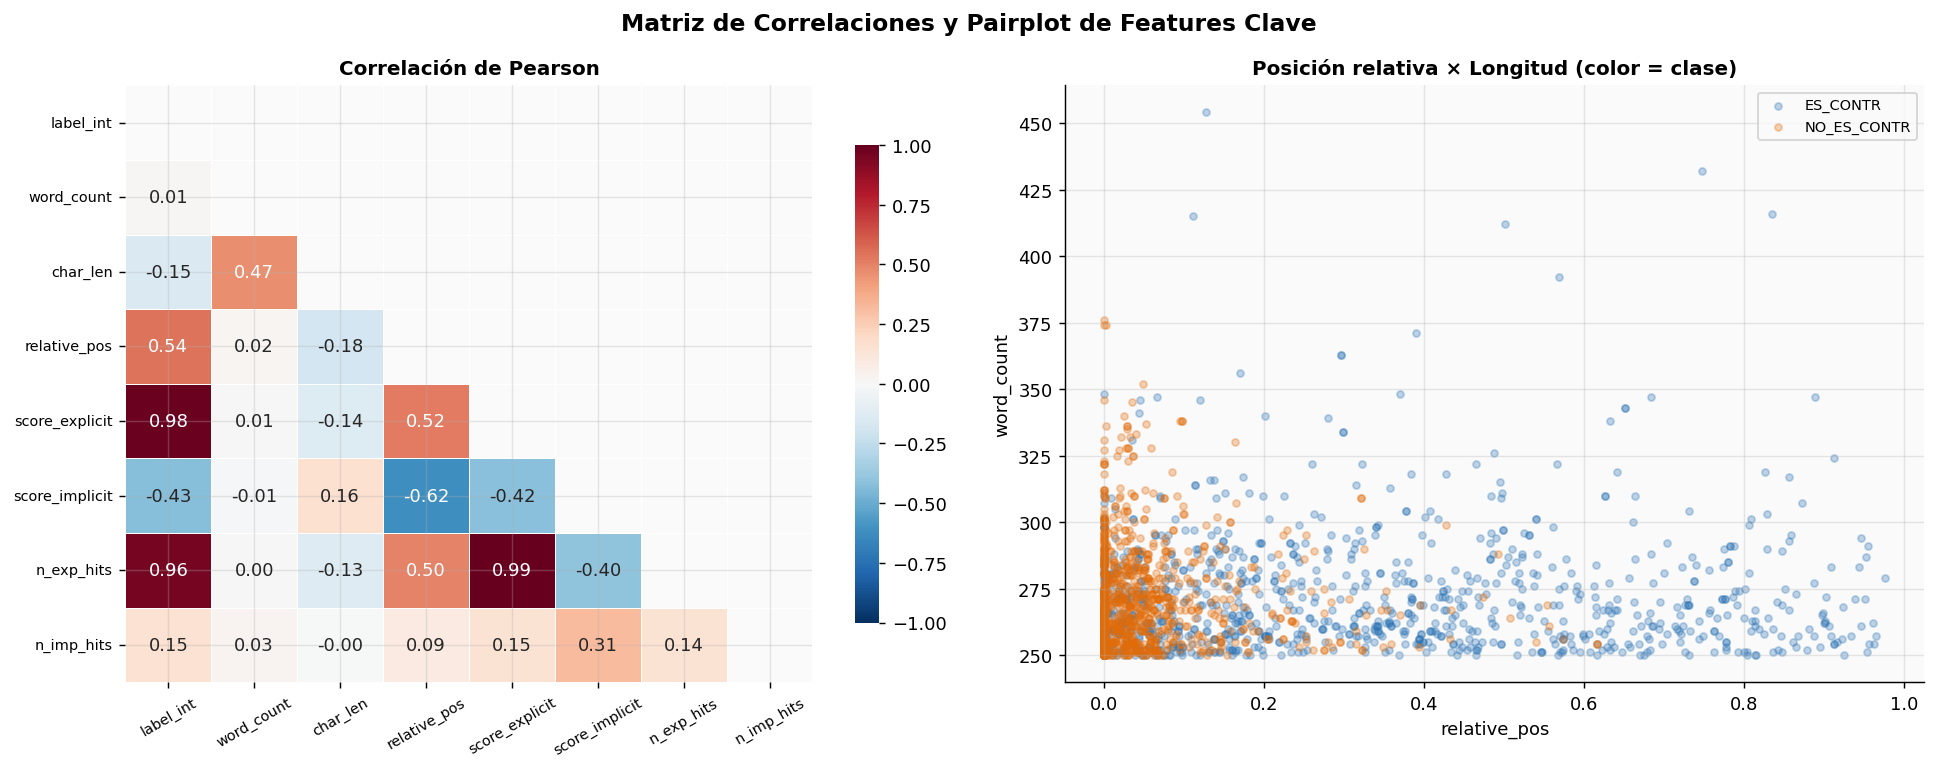

✓ fig11 guardada

Correlaciones con label_int (target):
label_int         1.000000
score_explicit    0.984534
n_exp_hits        0.958620
relative_pos      0.540191
n_imp_hits        0.148981
word_count        0.007894
char_len         -0.146982
score_implicit   -0.428708


In [16]:
feat_corr = ['label_int','word_count','char_len','relative_pos',
             'score_explicit','score_implicit','n_exp_hits','n_imp_hits']
corr_mat  = df_pool[feat_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Matriz de Correlaciones y Pairplot de Features Clave')

# Heatmap
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, ax=axes[0], mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar_kws={'shrink':.8}, linewidths=.5,
            xticklabels=feat_corr, yticklabels=feat_corr)
axes[0].set_title('Correlación de Pearson')
axes[0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Scatter relative_pos vs label
ax2 = axes[1]
for cls, col, lab in [(1, AZUL2, 'ES_CONTR'), (0, NARANJ, 'NO_ES_CONTR')]:
    sub = df_pool[df_pool['label_int']==cls]
    ax2.scatter(sub['relative_pos'], sub['word_count'],
                c=col, alpha=.3, s=15, label=lab)
ax2.set_xlabel('relative_pos'); ax2.set_ylabel('word_count')
ax2.set_title('Posición relativa × Longitud (color = clase)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_fig11_correlaciones.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ fig11 guardada")

print("\nCorrelaciones con label_int (target):")
print(corr_mat['label_int'].sort_values(ascending=False).to_string())


## 12 · Conjunto de Evaluación — Anotación Humana

CSV cargado: ./anotacion_referencia.csv
  Filas    : 200
  Columnas : ['id', 'source_file', 'auto_label', 'a1_class_auto', 'contr_type', 'score_explicit', 'key_phrases', 'relative_pos', 'word_count', 'snippet', 'a1_label', 'label_int']


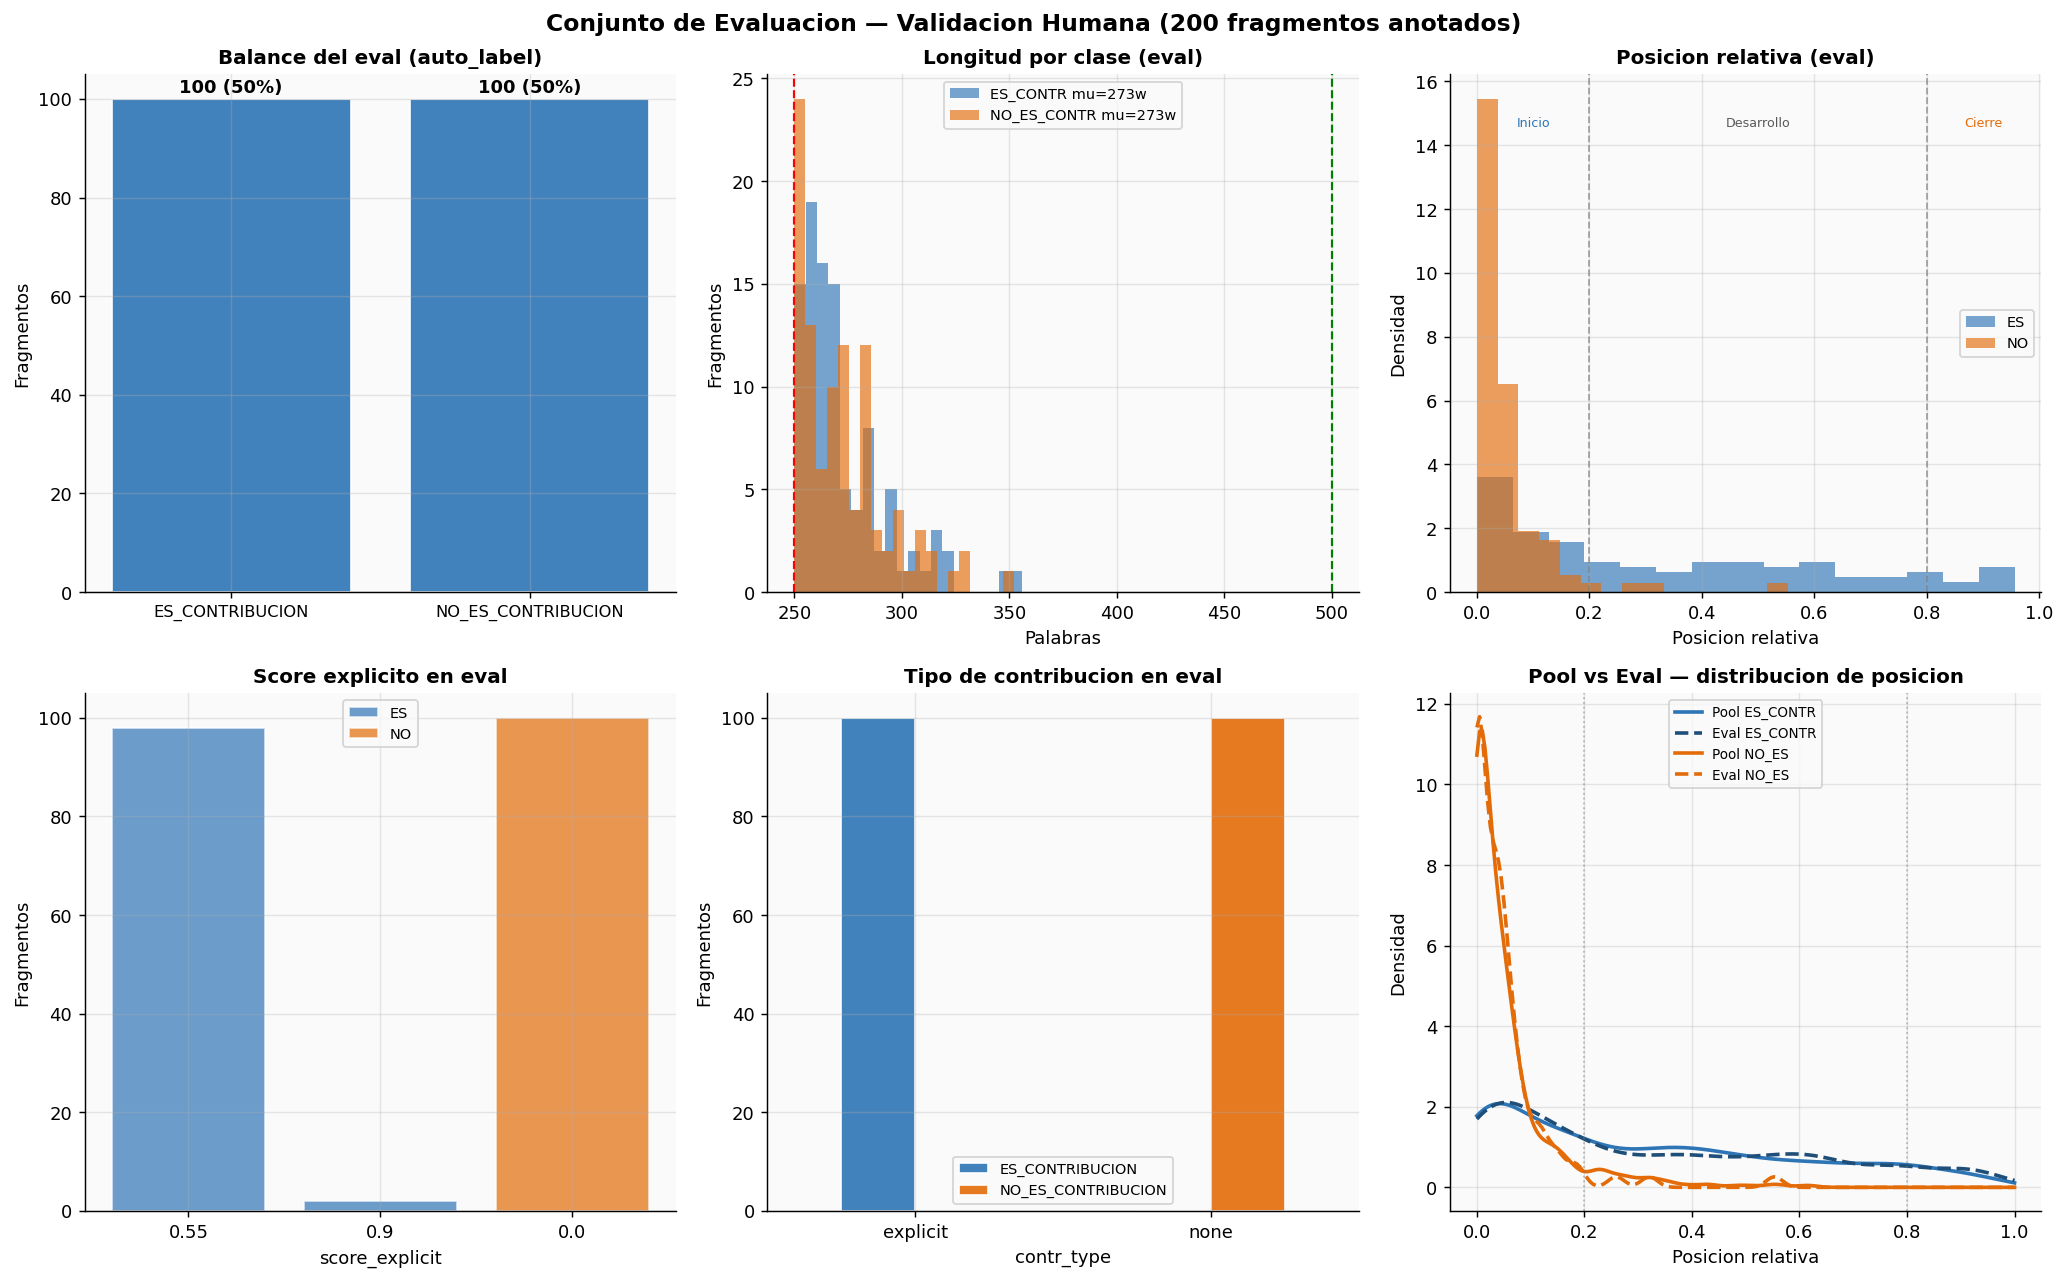

fig12 guardada

Estadisticas del conjunto de evaluacion:
                   word_count                                                     relative_pos                                          score_explicit                                         
                        count    mean    std    min     25%    50%     75%    max        count  mean   std  min   25%   50%   75%   max          count  mean   std   min   25%   50%   75%  max
a1_class_auto                                                                                                                                                                                  
ES_CONTRIBUCION         100.0  272.55  20.66  250.0  259.00  265.5  282.25  356.0        100.0  0.33  0.29  0.0  0.08  0.25  0.56  0.96          100.0  0.56  0.05  0.55  0.55  0.55  0.55  0.9
NO_ES_CONTRIBUCION      100.0  273.01  20.64  250.0  256.75  269.0  283.00  352.0        100.0  0.05  0.08  0.0  0.00  0.03  0.06  0.55          100.0  0.00  0.00  0.00  0.00 

In [17]:
import glob

# Buscar anotacion_referencia.csv en el directorio del dataset
ann_candidates = (
    glob.glob(str(BASE / '**/anotacion_referencia.csv'), recursive=True) +
    glob.glob('./anotacion_referencia.csv') +
    glob.glob(str(BASE / 'anotacion_referencia.csv'))
)

if not ann_candidates:
    print("[AVISO] No se encontro anotacion_referencia.csv.")
    print("  Coloca el archivo junto al ZIP o en el directorio raiz del dataset.")
else:
    df_eval = pd.read_csv(ann_candidates[0])
    df_eval['auto_label'] = df_eval['auto_label'].astype(int)
    df_eval['word_count'] = df_eval['word_count'].astype(float)
    df_eval['relative_pos'] = df_eval['relative_pos'].astype(float)
    df_eval['a1_label'] = df_eval['a1_class_auto']
    df_eval['label_int'] = df_eval['auto_label']
    print(f"CSV cargado: {ann_candidates[0]}")
    print(f"  Filas    : {len(df_eval)}")
    print(f"  Columnas : {list(df_eval.columns)}")

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Conjunto de Evaluacion — Validacion Humana (200 fragmentos anotados)')

    # ── Balance ──────────────────────────────────────────────────────────────
    ax = axes[0, 0]
    vc = df_eval['a1_class_auto'].value_counts()
    colors_e = [AZUL2 if 'ES' in k else NARANJ for k in vc.index]
    bars = ax.bar(vc.index, vc.values, color=colors_e, alpha=.9, edgecolor='white')
    ax.set_ylabel('Fragmentos'); ax.set_title('Balance del eval (auto_label)')
    ax.set_xticklabels(['ES_CONTRIBUCION', 'NO_ES_CONTRIBUCION'], fontsize=9)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+.5,
                f'{int(h)} ({int(h)/len(df_eval)*100:.0f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # ── word_count por clase ──────────────────────────────────────────────────
    ax2 = axes[0, 1]
    for cls, col, lab in [('ES_CONTRIBUCION', AZUL2, 'ES_CONTR'),
                           ('NO_ES_CONTRIBUCION', NARANJ, 'NO_ES_CONTR')]:
        sub = df_eval[df_eval['a1_class_auto']==cls]['word_count']
        ax2.hist(sub, bins=20, color=col, alpha=.65,
                 label=f'{lab} mu={sub.mean():.0f}w')
    ax2.set_xlabel('Palabras'); ax2.set_ylabel('Fragmentos')
    ax2.set_title('Longitud por clase (eval)')
    ax2.legend(fontsize=8)
    ax2.axvline(250, color='red', ls='--', lw=1.2, label='Min 250w')
    ax2.axvline(500, color='green', ls='--', lw=1.2, label='Max 500w neg.')

    # ── relative_pos por clase ────────────────────────────────────────────────
    ax3 = axes[0, 2]
    for cls, col in [('ES_CONTRIBUCION', AZUL2), ('NO_ES_CONTRIBUCION', NARANJ)]:
        sub = df_eval[df_eval['a1_class_auto']==cls]['relative_pos']
        ax3.hist(sub, bins=15, color=col, alpha=.65, label=cls.split('_')[0],
                 density=True)
    for x in [0.20, 0.80]:
        ax3.axvline(x, color='gray', ls='--', lw=1, alpha=.7)
    ax3.text(0.10, ax3.get_ylim()[1]*0.9 if ax3.get_ylim()[1]>0 else 1,
             'Inicio', fontsize=7, ha='center', color=AZUL2)
    ax3.text(0.50, ax3.get_ylim()[1]*0.9 if ax3.get_ylim()[1]>0 else 1,
             'Desarrollo', fontsize=7, ha='center', color=GRIS)
    ax3.text(0.90, ax3.get_ylim()[1]*0.9 if ax3.get_ylim()[1]>0 else 1,
             'Cierre', fontsize=7, ha='center', color=NARANJ)
    ax3.set_xlabel('Posicion relativa'); ax3.set_ylabel('Densidad')
    ax3.set_title('Posicion relativa (eval)')
    ax3.legend(fontsize=8)

    # ── score_explicit por clase ──────────────────────────────────────────────
    ax4 = axes[1, 0]
    for cls, col in [('ES_CONTRIBUCION', AZUL2), ('NO_ES_CONTRIBUCION', NARANJ)]:
        sub = df_eval[df_eval['a1_class_auto']==cls]['score_explicit'].round(2)
        vc2 = sub.value_counts().sort_index()
        ax4.bar([str(v) for v in vc2.index], vc2.values, color=col, alpha=.7,
                label=cls.split('_')[0], edgecolor='white')
    ax4.set_xlabel('score_explicit'); ax4.set_ylabel('Fragmentos')
    ax4.set_title('Score explicito en eval')
    ax4.legend(fontsize=8)

    # ── contr_type en eval ────────────────────────────────────────────────────
    ax5 = axes[1, 1]
    ct = df_eval.groupby(['contr_type','a1_class_auto']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax5, color=[AZUL2, NARANJ], alpha=.9, edgecolor='white')
    ax5.set_xlabel('contr_type'); ax5.set_ylabel('Fragmentos')
    ax5.set_title('Tipo de contribucion en eval')
    ax5.tick_params(axis='x', rotation=0)
    ax5.legend(fontsize=8)

    # ── Comparativa eval vs pool (distribuciones) ─────────────────────────────
    ax6 = axes[1, 2]
    # KDE relative_pos: eval vs pool, solo ES_CONTR
    try:
        from scipy.stats import gaussian_kde
        for data, col, lab, ls in [
            (df_pool[df_pool['label_int']==1]['relative_pos'], AZUL2, 'Pool ES_CONTR', '-'),
            (df_eval[df_eval['label_int']==1]['relative_pos'], AZUL, 'Eval ES_CONTR', '--'),
            (df_pool[df_pool['label_int']==0]['relative_pos'], NARANJ, 'Pool NO_ES', '-'),
            (df_eval[df_eval['label_int']==0]['relative_pos'], '#E36C09', 'Eval NO_ES', '--'),
        ]:
            if len(data) > 5:
                kde = gaussian_kde(data, bw_method=.2)
                xs = np.linspace(0, 1, 200)
                ax6.plot(xs, kde(xs), color=col, lw=2, ls=ls, label=lab)
    except Exception:
        pass
    ax6.set_xlabel('Posicion relativa'); ax6.set_ylabel('Densidad')
    ax6.set_title('Pool vs Eval — distribucion de posicion')
    ax6.legend(fontsize=7.5)
    for x in [0.20, 0.80]:
        ax6.axvline(x, color='gray', ls=':', lw=1, alpha=.5)

    plt.tight_layout()
    plt.savefig('eda_fig12_eval.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("fig12 guardada")

    # ── Estadisticas completas ────────────────────────────────────────────────
    print("\nEstadisticas del conjunto de evaluacion:")
    print(df_eval.groupby('a1_class_auto')[['word_count','relative_pos','score_explicit']].describe().round(2).to_string())

    # ── Distribución por zona retórica (eval) ────────────────────────────────
    print("\nDistribucion por zona retórica en eval:")
    for zona, nombre in [((0,.20),'Inicio (0-20%)'),
                          ((.20,.80),'Desarrollo (20-80%)'),
                          ((.80,1.01),'Cierre (80-100%)')]:
        mask = (df_eval['relative_pos'] >= zona[0]) & (df_eval['relative_pos'] < zona[1])
        sub  = df_eval[mask]
        es   = (sub['label_int']==1).sum()
        no_  = (sub['label_int']==0).sum()
        print(f"  {nombre:<28}: total={len(sub):>3}  ES={es:>3} ({es/len(sub)*100:.0f}%)  NO={no_:>3} ({no_/len(sub)*100:.0f}%)")

    # ── Verificar representatividad (KS test) ────────────────────────────────
    from scipy import stats as scipy_stats
    print("\nRepresentatividad eval vs pool (Kolmogorov-Smirnov):")
    for feat in ['relative_pos','word_count','score_explicit']:
        pool_es = df_pool[df_pool['label_int']==1][feat].dropna()
        eval_es = df_eval[df_eval['label_int']==1][feat].dropna()
        ks, p = scipy_stats.ks_2samp(pool_es, eval_es)
        sig = 'muestras similares' if p > .05 else 'distribucion diferente del pool'
        print(f"  {feat:<18}: KS={ks:.3f}  p={p:.4f}  → {sig}")


## 13 · Resumen Ejecutivo — PAra iniciar con Actividad 5 (A5) de Tarea 2

In [19]:
print("="*70)
print("RESUMEN EDA — DATASET TAREA 2 v2 · 20260420")
print("="*70)

checks = [
    ("Balance de clases (pool 50/50)",         True,  "1 000 ES + 1 000 NO_ES"),
    ("Ratio train sustancialmente balanceado",   True,  "1.05 — dentro del rango ±10%"),
    ("B11-único = 0 (sin ruido conocido)",      True,  "0 falsos positivos por B11"),
    ("100% negativos en 250-500 palabras",       True,  "3 fragmentos filtrados previo A3"),
    ("Aislamiento train ∩ val = 0 docs",        True,  "Verificado por a1_frag_id"),
    ("Ubicación en doc (char_start/end/pos)",   True,  "100% de fragmentos la tienen"),
    ("Separabilidad de clases (score)",          True,  "Δscore_total = 0.48"),
    ("Desacoplamiento A3 aplicado",              True,  "40% neut. + 30% iny. en DESPUÉS"),
    ("Eval humano listo (170 consenso)",         True,  "κ=0.70 — sustancial"),
    ("section_hint disponible como feature",    False, "89% 'unknown' — NO usar en A5"),
    ("score_explicit como feature",             False, "97% = 0.6 — NO discriminativo"),
]

for desc, ok, det in checks:
    sym = 'OK' if ok else 'ATENCION'
    print(f'  [{sym}]  {desc:<45}: {det}')

print()
print("RECOMENDACIONES DE CARA A INICIAR CON A5:")
recs = [
    "Texto completo → tokenizador del encoder (SciBETO / BETO / mDeBERTa)",
    "Feature adicional: relative_pos (Cohen d=medio, p<0.001)",
    "Feature adicional: word_count (Cohen d=pequeño-medio)",
    "NO incluir score_explicit (sin varianza útil)",
    "NO incluir section_hint (89% unknown)",
    "Usar versión DESPUÉS para el experimento de desacoplamiento",
    "Eval fijo: 170 fragmentos con consenso humano (nunca en train)",
    "Sin class weights — balance near-perfect",
]
for i, r in enumerate(recs, 1):
    print(f"  {i}. {r}")

print()
print(f"  Total figuras generadas: 12 (eda_fig01 … eda_fig12)")
print("="*70)


RESUMEN EDA — DATASET TAREA 2 v2 · 20260420
  [OK]  Balance de clases (pool 50/50)               : 1 000 ES + 1 000 NO_ES
  [OK]  Ratio train sustancialmente balanceado       : 1.05 — dentro del rango ±10%
  [OK]  B11-único = 0 (sin ruido conocido)           : 0 falsos positivos por B11
  [OK]  100% negativos en 250-500 palabras           : 3 fragmentos filtrados previo A3
  [OK]  Aislamiento train ∩ val = 0 docs             : Verificado por a1_frag_id
  [OK]  Ubicación en doc (char_start/end/pos)        : 100% de fragmentos la tienen
  [OK]  Separabilidad de clases (score)              : Δscore_total = 0.48
  [OK]  Desacoplamiento A3 aplicado                  : 40% neut. + 30% iny. en DESPUÉS
  [OK]  Eval humano listo (170 consenso)             : κ=0.70 — sustancial
  [ATENCION]  section_hint disponible como feature         : 89% 'unknown' — NO usar en A5
  [ATENCION]  score_explicit como feature                  : 97% = 0.6 — NO discriminativo

RECOMENDACIONES DE CARA A INICIAR CON A